In the name of God

# **CA2: Boosted Trees for Feature Generation in SVM/LDA**

Seyed Mani Mirshabani
801801080

In this homework we are going to implement a classification pipeline and use the breast cancer wisconsin dataset to preform data preprocessing, feature engineering (using gradient boosting), and classification with SVM and LDA.

## 1. Understanding the Dataset

### 1.1. Downloading the Dataset

According to the host website of the dataset (https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) the dataset can be downloaded with the following commands: (first however we need to install the ucimlrepo library with "pip install ucimlrepo")

In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

cancer_dataset = pd.concat([X, y], axis=1)
cancer_dataset.rename(columns={'Diagnosis': 'diagnosis'}, inplace=True)

### 1.2. Dataset Overview

In [2]:
cancer_dataset.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [3]:
cancer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

In [4]:
cancer_dataset.shape

(569, 31)

As we can see the dataset contains 569 instances with 30 numerical features which describe a tumor (such as radios, texture, ...). The target valuable is the diagnosis which states wether or not a tumor is malignant.

According to the website the features were extracted from digitized images of fine needle aspirates (FNA) of breast masses.

### 1.3. Target Variable

As stated earlier the target variable shows weather the tumor is malignant (M) or benign (B), we will use this to train the model to be able to predict the state of the tumor.

In [5]:
cancer_dataset.diagnosis.value_counts

<bound method IndexOpsMixin.value_counts of 0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object>

### 4.1. Feature Analysis

As we saw earlier the dataset has 30 numerical features which according to the description is grouped as follows:

- **First 10 features:** Mean values of cell properties.  
- **Second 10 features:** Standard deviation (std) values of the same properties.  
- **Final 10 features:** Worst (largest) values recorded.  

Now we will take a quick look at the statistical properties of different columns (such ast their mean, std, etc)

In [6]:
cancer_dataset.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 1.5. Exploratory Data Analysis

In this section we will be performing EDA, we will:

1. Visualize feature distributions (and find the outliers)
2. Check correlations with heatmap

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

#### 1.5.1. Feature distributions & plots

In [8]:
feature_cols = cancer_dataset.columns.drop('diagnosis')

suffix_map = {'1': 'Mean', '2': 'STD', '3': 'Worst'}

def get_clean_title(col_name):
    match = re.match(r"([a-zA-Z_]+)(\d)$", col_name)
    if match:
        base_name, suffix = match.groups()
        clean_suffix = suffix_map.get(suffix, '')
        return f'Distribution of {clean_suffix} {base_name.replace("_", " ").title()}'
    return col_name

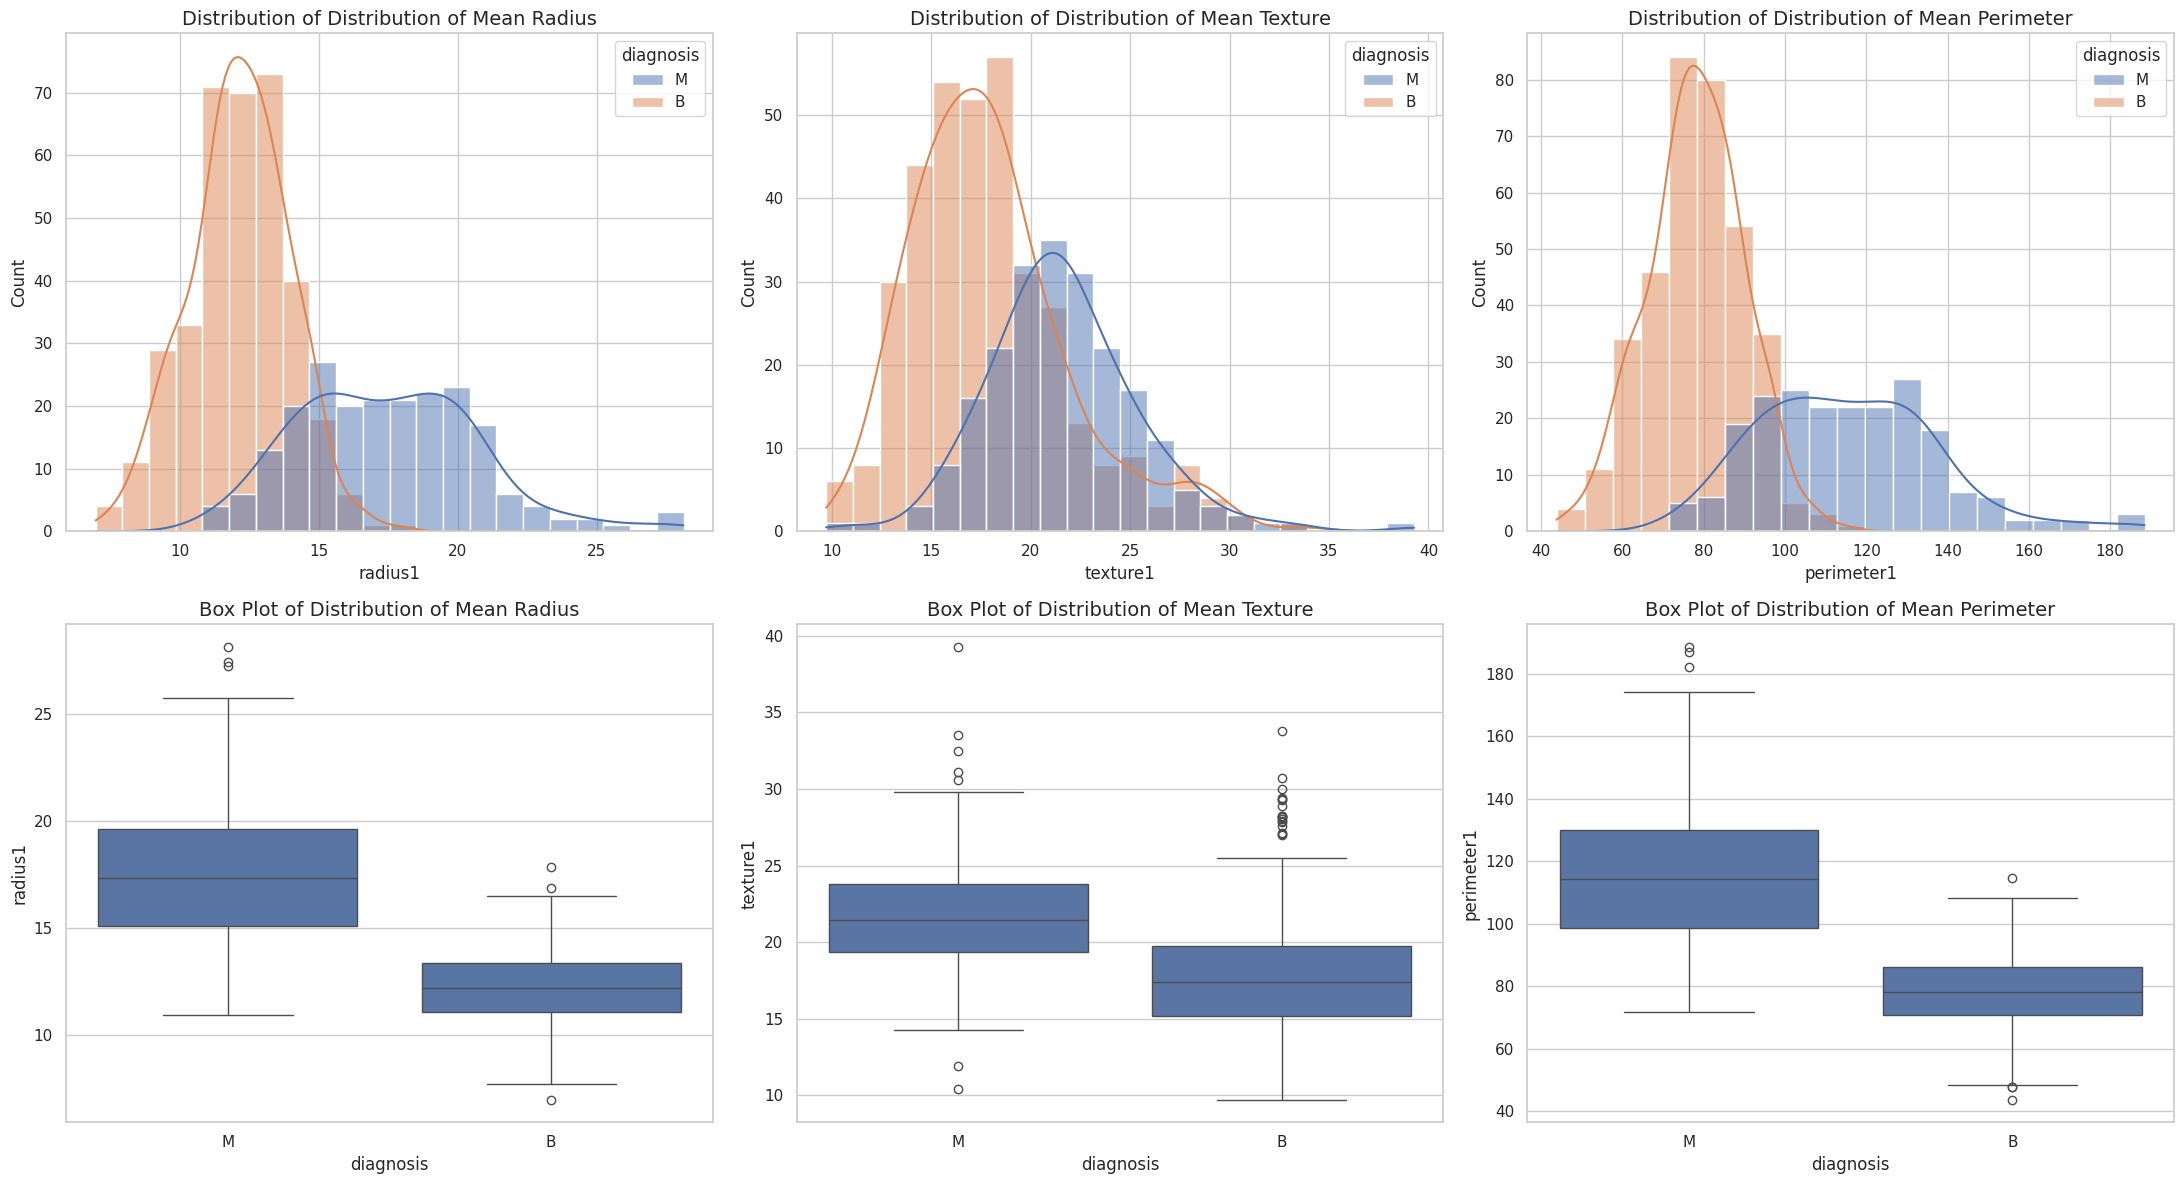

In [9]:
batch_1_features = feature_cols[0:3]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_1_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

As we can see overall the malignant (M) class had a higher value in terms of all three features, we can also see that the distribution of benign (B) class was almost normal but the malignant class (in radius and perimeter) wasn't this way.

We can also see from the box plots tah teh mean texture feature had quite a few more outliers in the benign class!

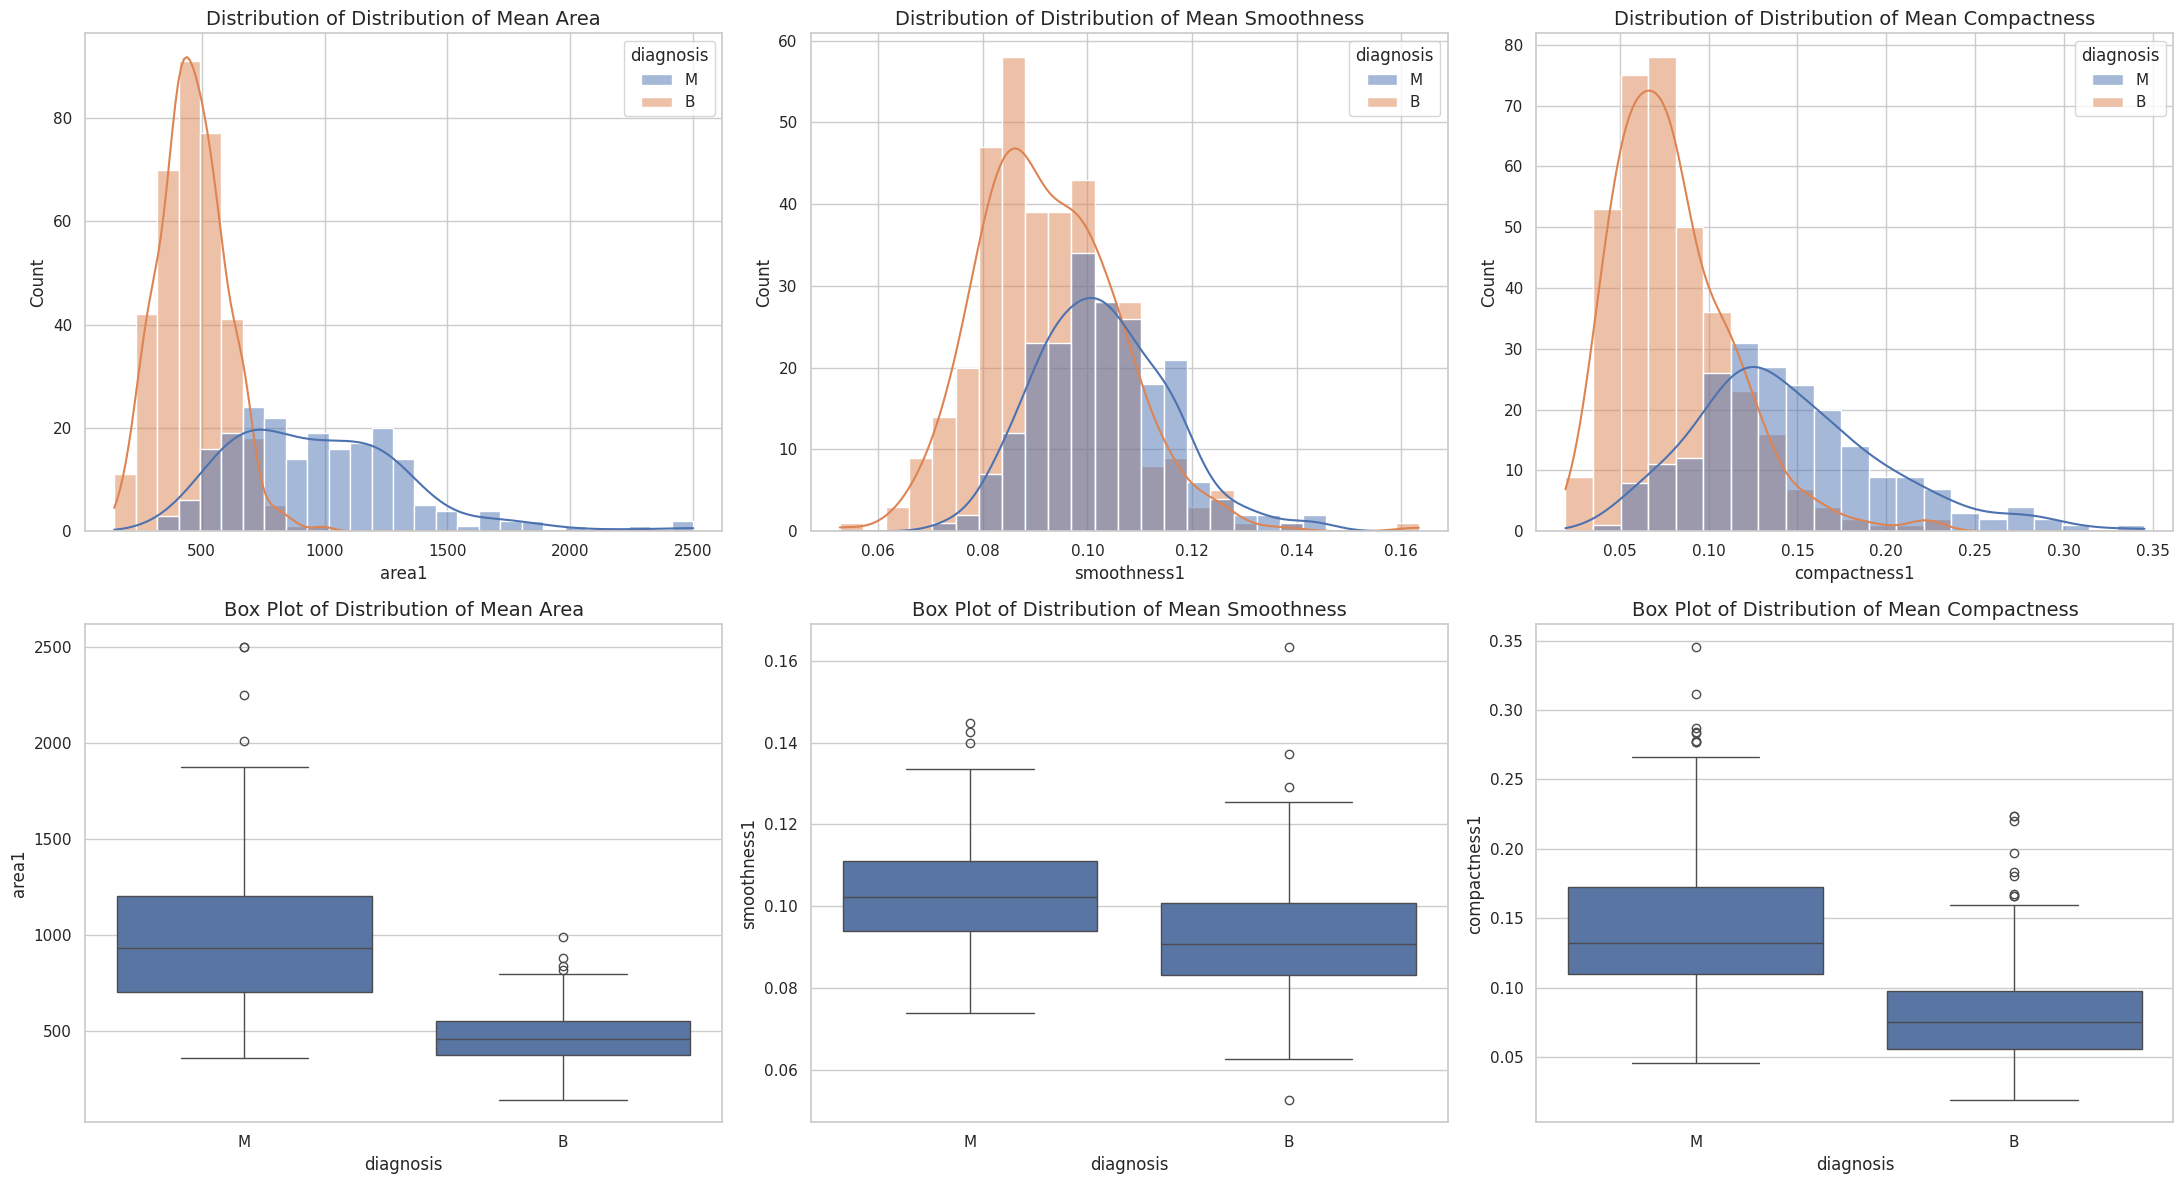

In [10]:
batch_2_features = feature_cols[3:6]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_2_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

In this batch we can see that the difference in distribution of mean area and mean compactness is quite significant between the two classes which suggests these two features could be quite useful. It's not quite the same with the other feature (mean smoothness) and both classes have rather similar distributions!

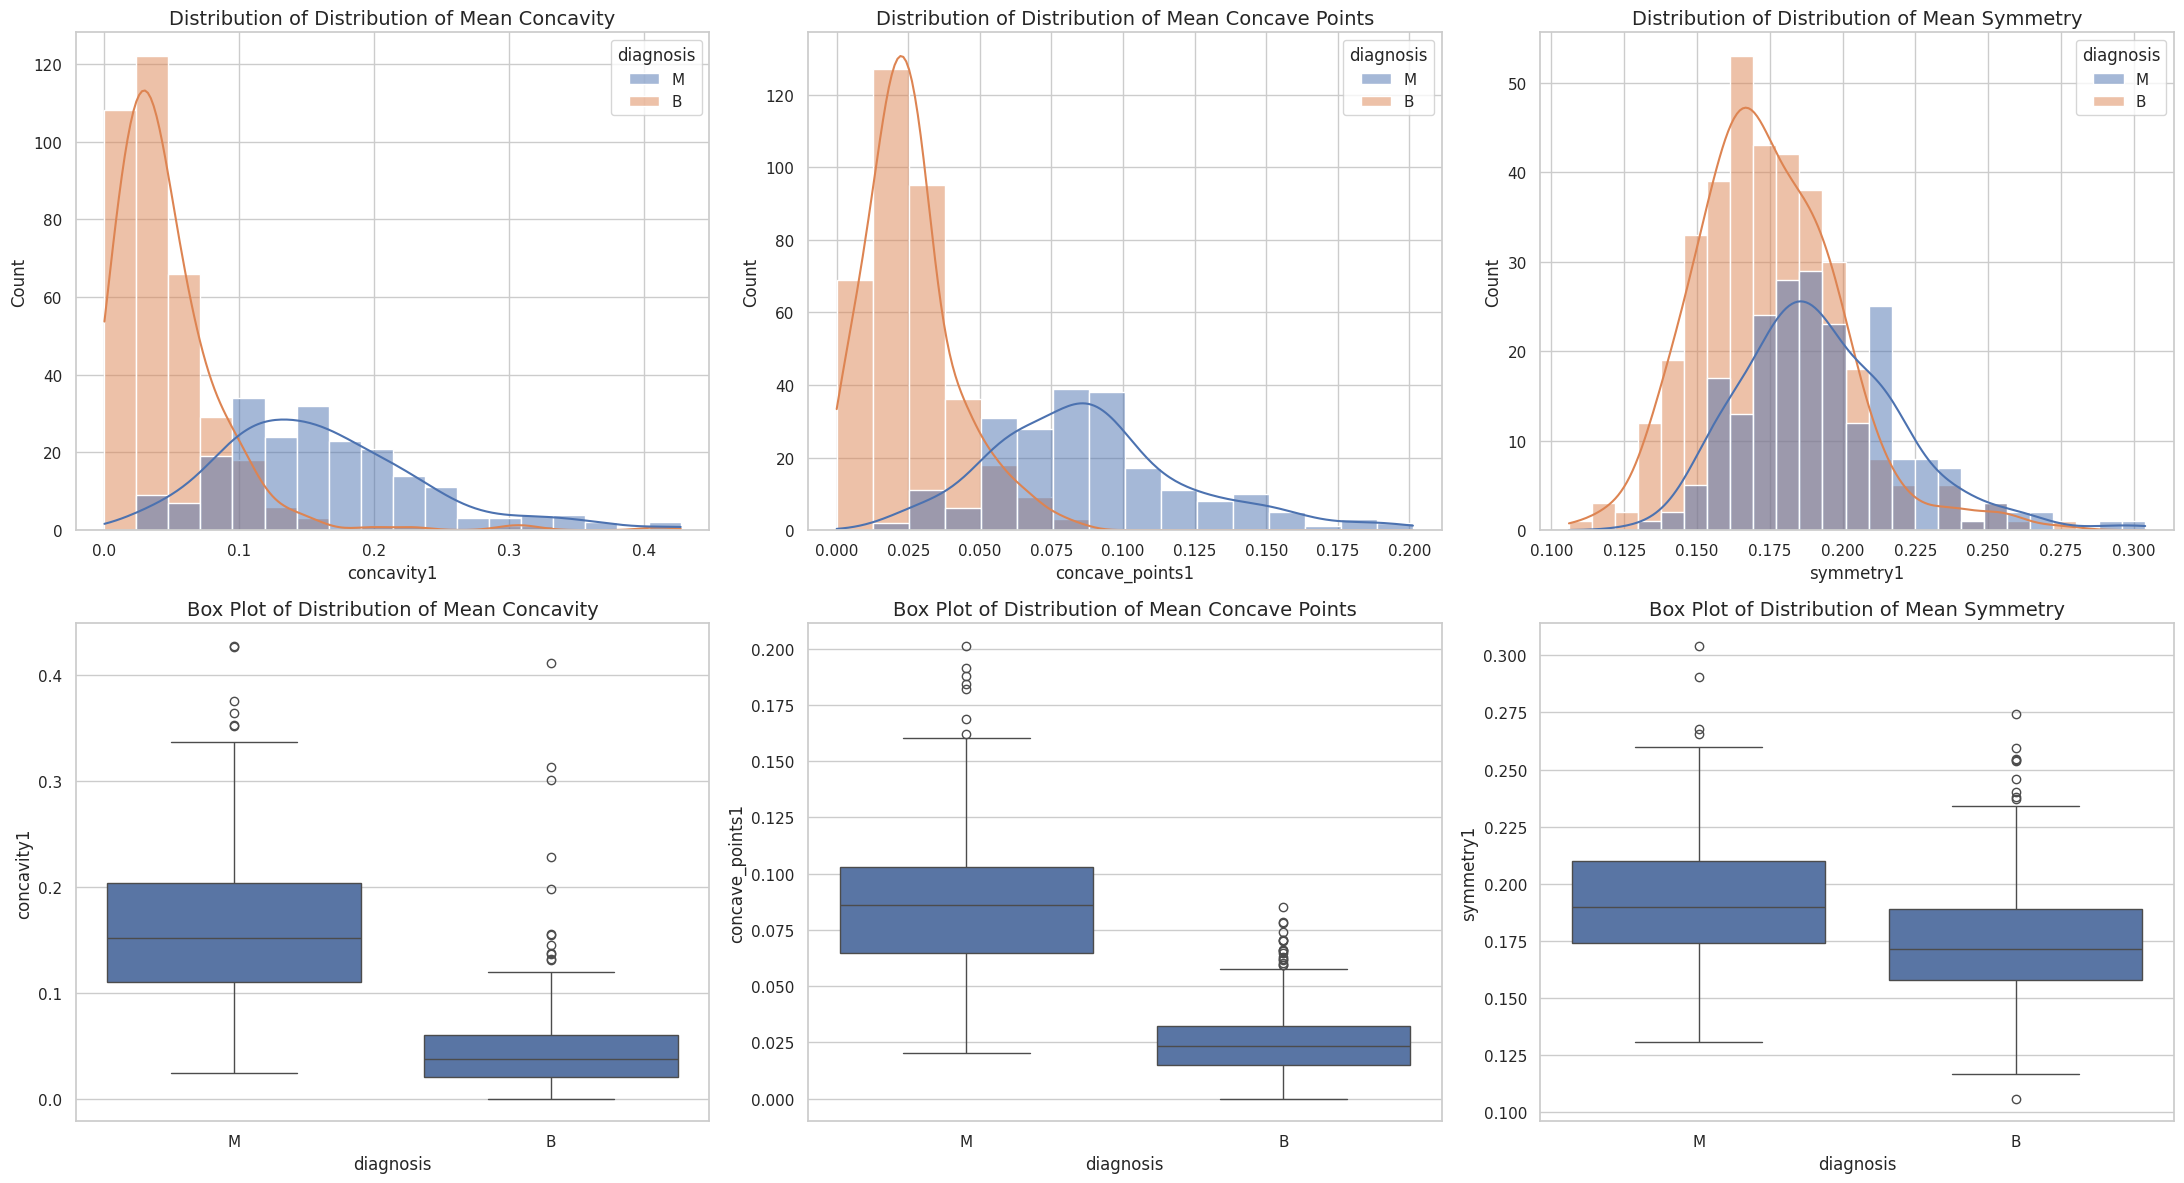

In [11]:
batch_3_features = feature_cols[6:9]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_3_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

Again we see a high shift between the B and M class for two of the features (mean concavity and mean concave points, which according to their name appear to relate to roughly the same concept), meaning these two can be valuable features for our classification algorithms.

It's not the same with the mean symmetry class however and the distribution of the two classes are quite similar here!

From the box plots we can see that the mean concavity feature had quite a few benign outliers that almost covered the full span of the malignant class! the number of outlier in the mean concave points were quite high too.

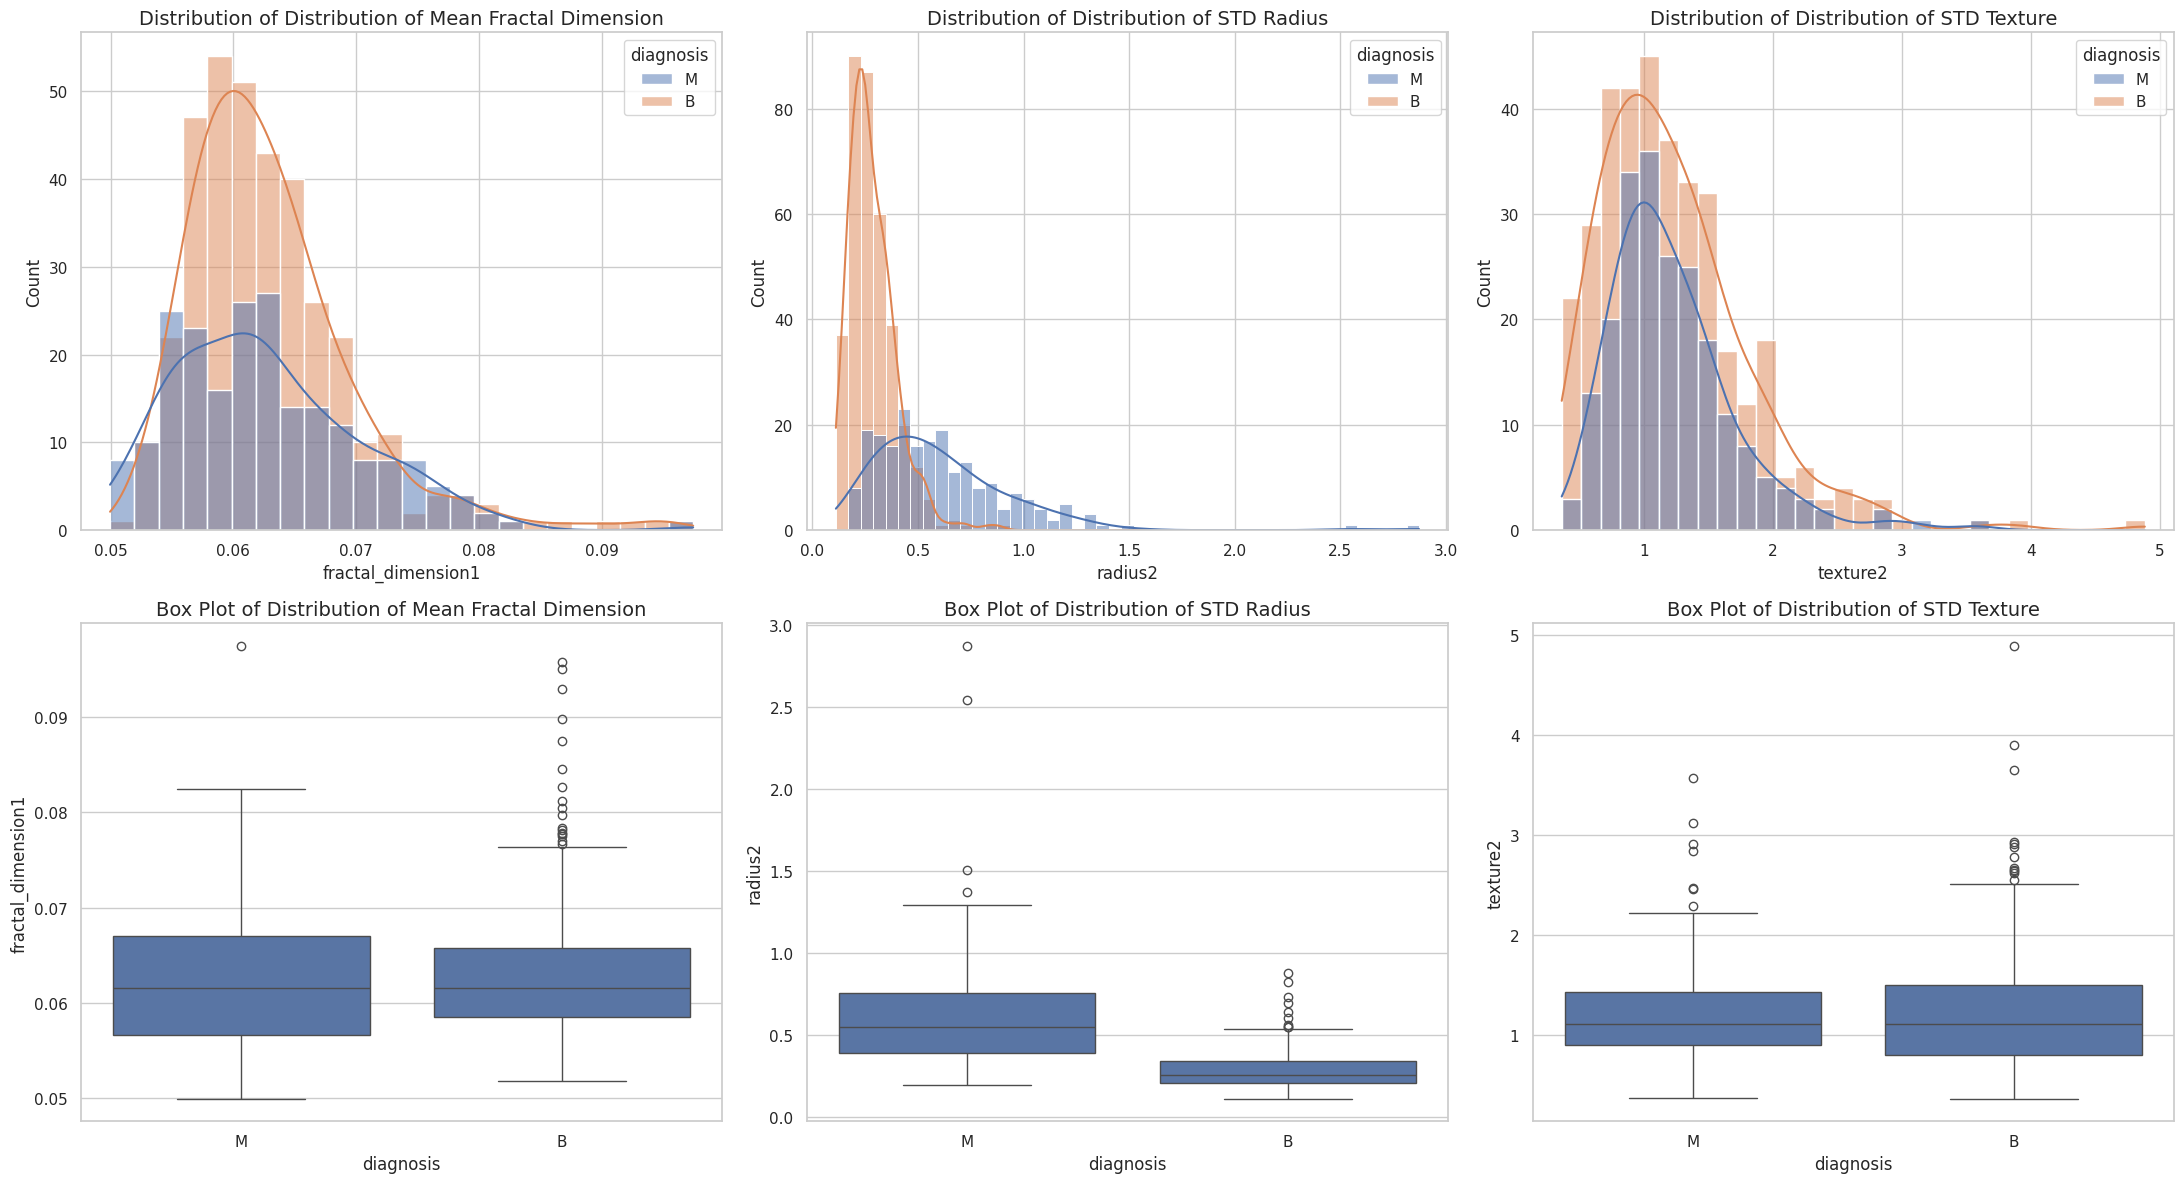

In [12]:
batch_4_features = feature_cols[9:12]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_4_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

For these three features we can see that the difference in distribution is quite visible in STD Radius but the other two are quite similar (with the STD Texture having almost identical distribution for both classes)

Again from the box plots we see that the number of outliers in the benign class is much higher that the malignant class (especially in mean fractal dimension and std texture)

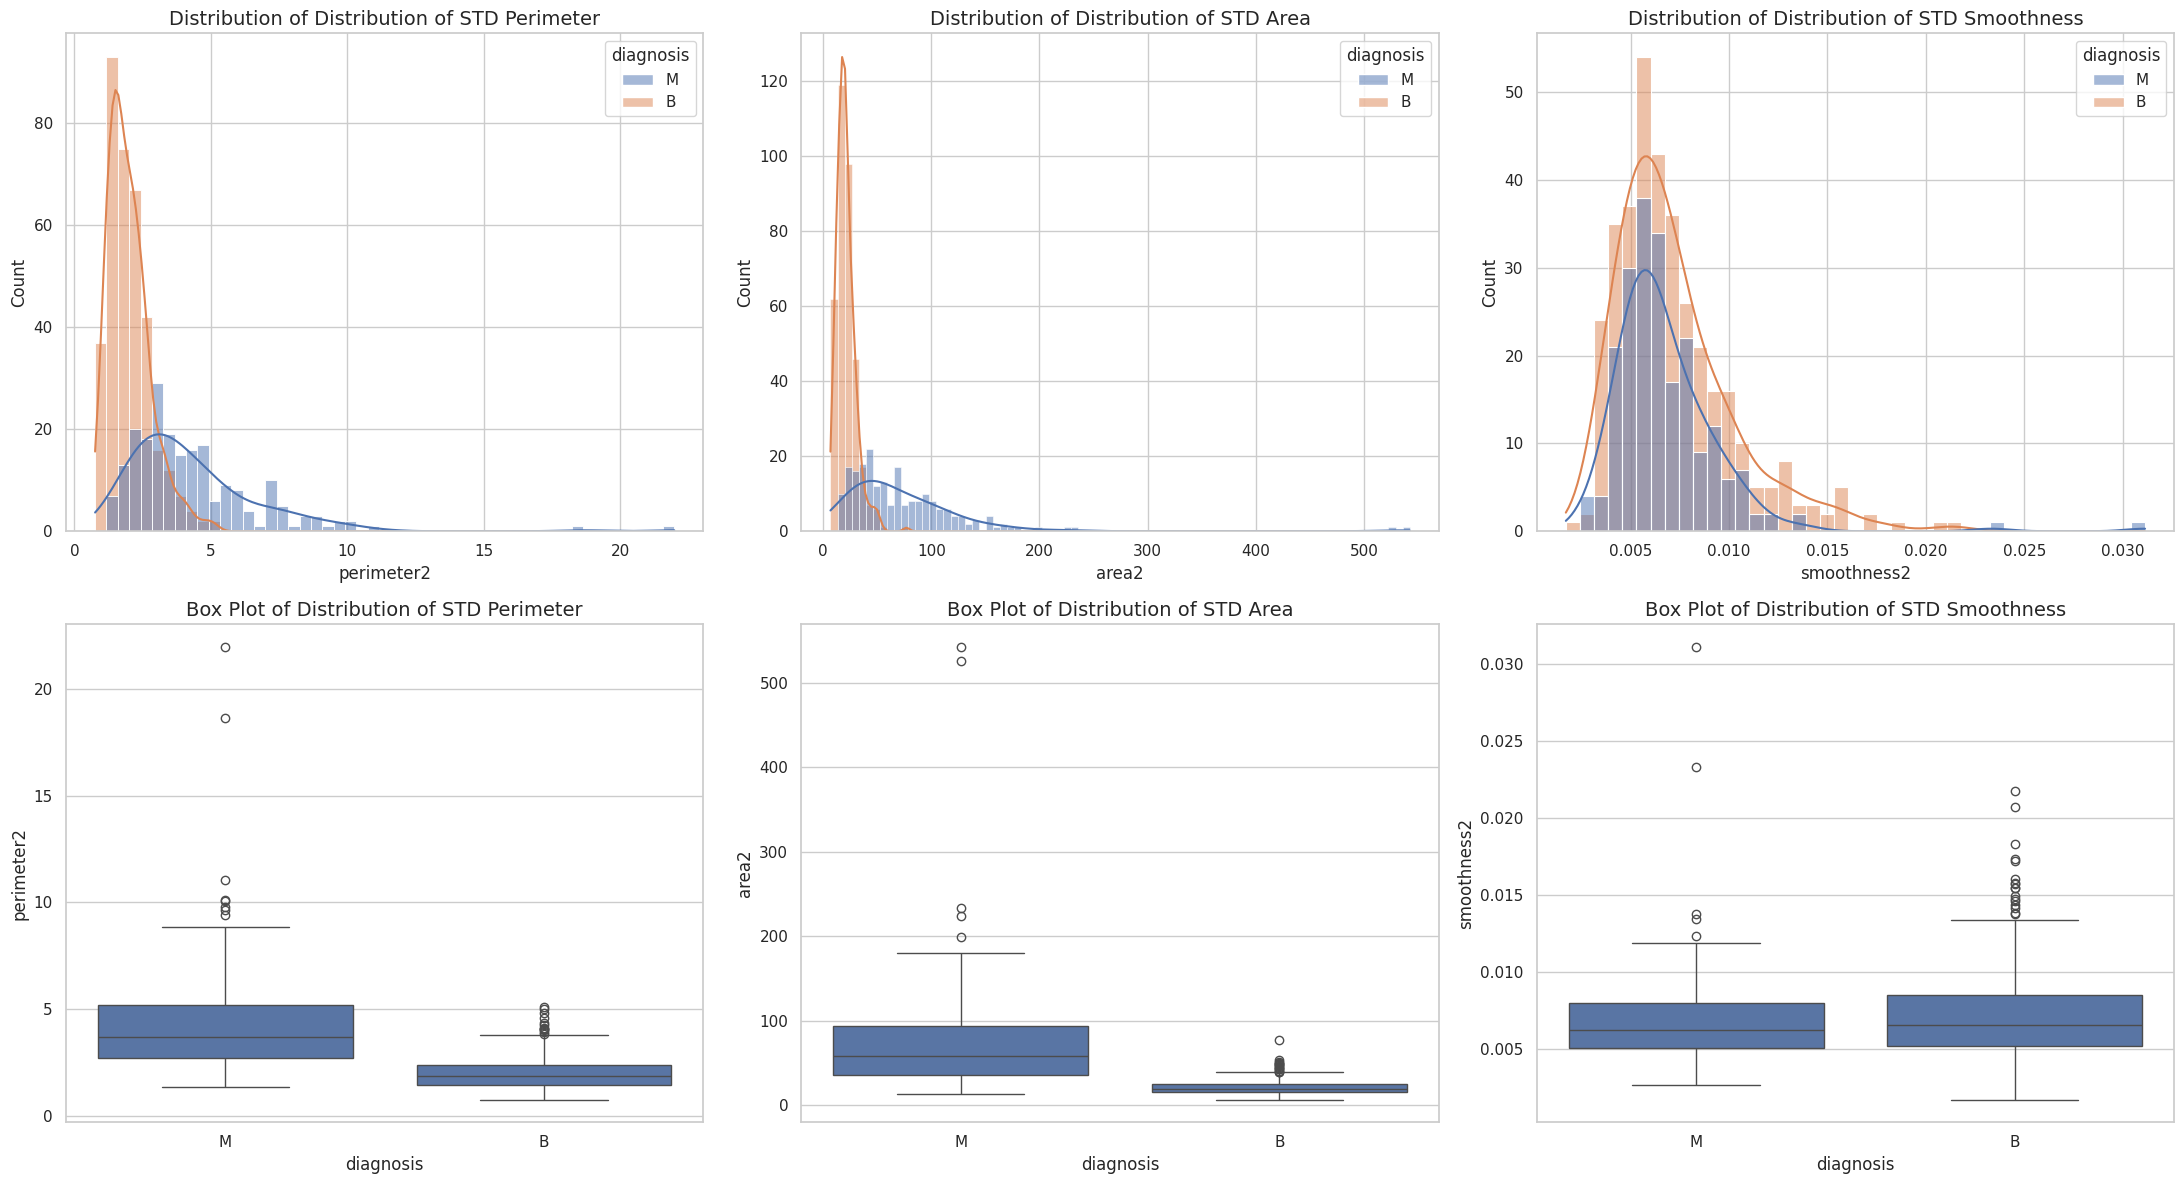

In [13]:
batch_5_features = feature_cols[12:15]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_5_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

Here we can see the benign tumors have a much narrower std perimeter and area (which are two highly related features) compared to malignant tumors, showing that benign tumors probably have a more structured form.

the std of smoothness of the two classes are quite similar however, so this is probably not a useful feature and if we were to manually pick some features (and not use methods like PCA) we would probably omit this one.

We can also see from the box plot that the distribution of std perimeter and area of benign tumors has quite a narrow span (even the outliers are quite close to other samples). This difference between the two classes can be quite helpful for the classification algorithm.

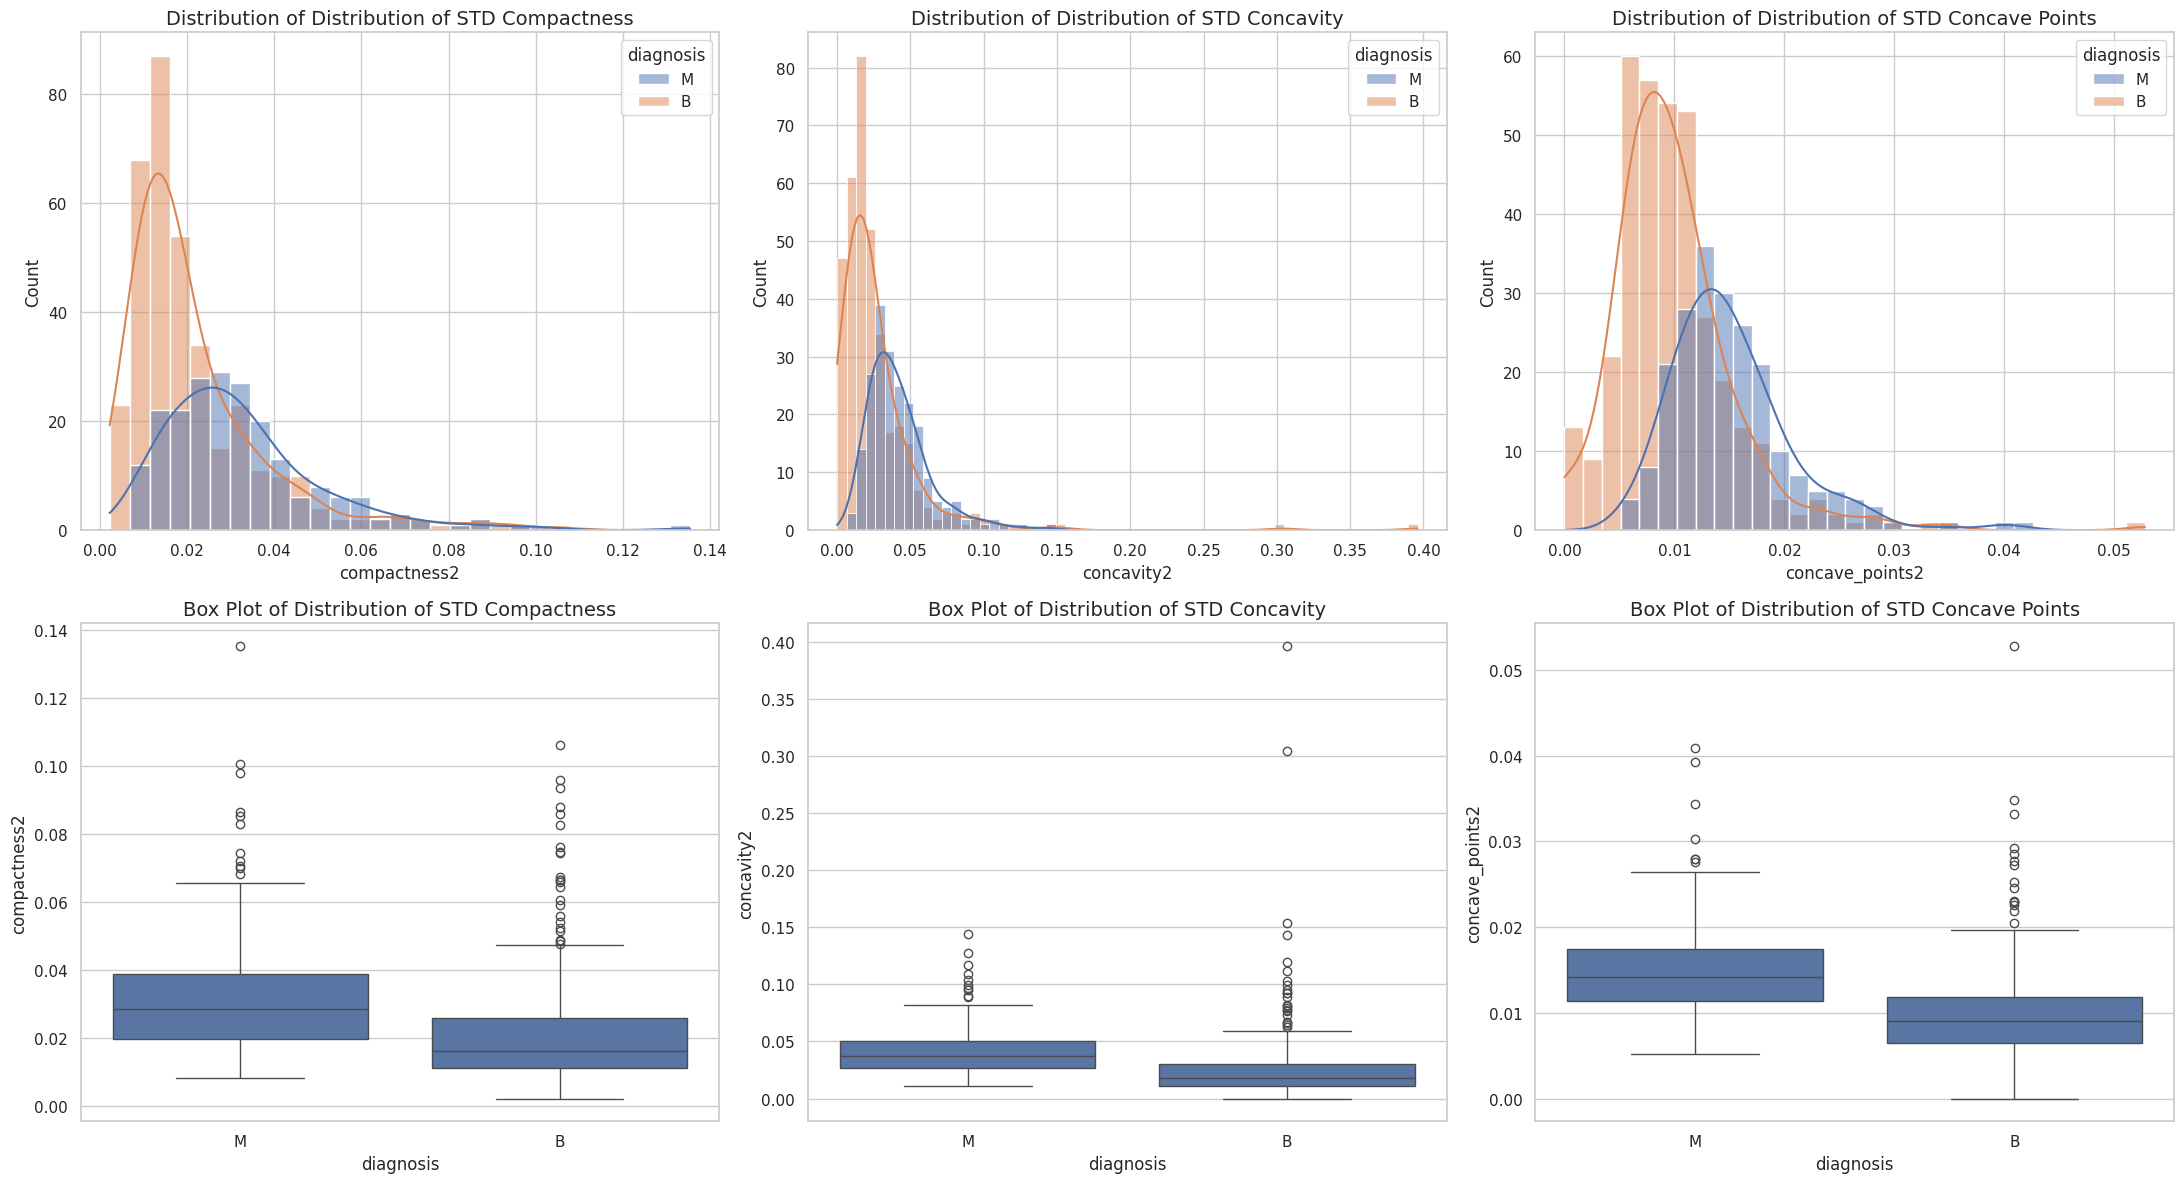

In [14]:
batch_6_features = feature_cols[15:18]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_6_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

From these three features we can see that while the distribution of std compactness is somewhat different between the two classes, std concavity and stc concave points (which again probably relate to the same concept and are highly correlated) are have a similar distribution among the two classes.

Similar to other features we can see that the benign class has quite a few more outliers which are sometimes even more distant than the outliers of malignant (especially fro the std concavity feature)

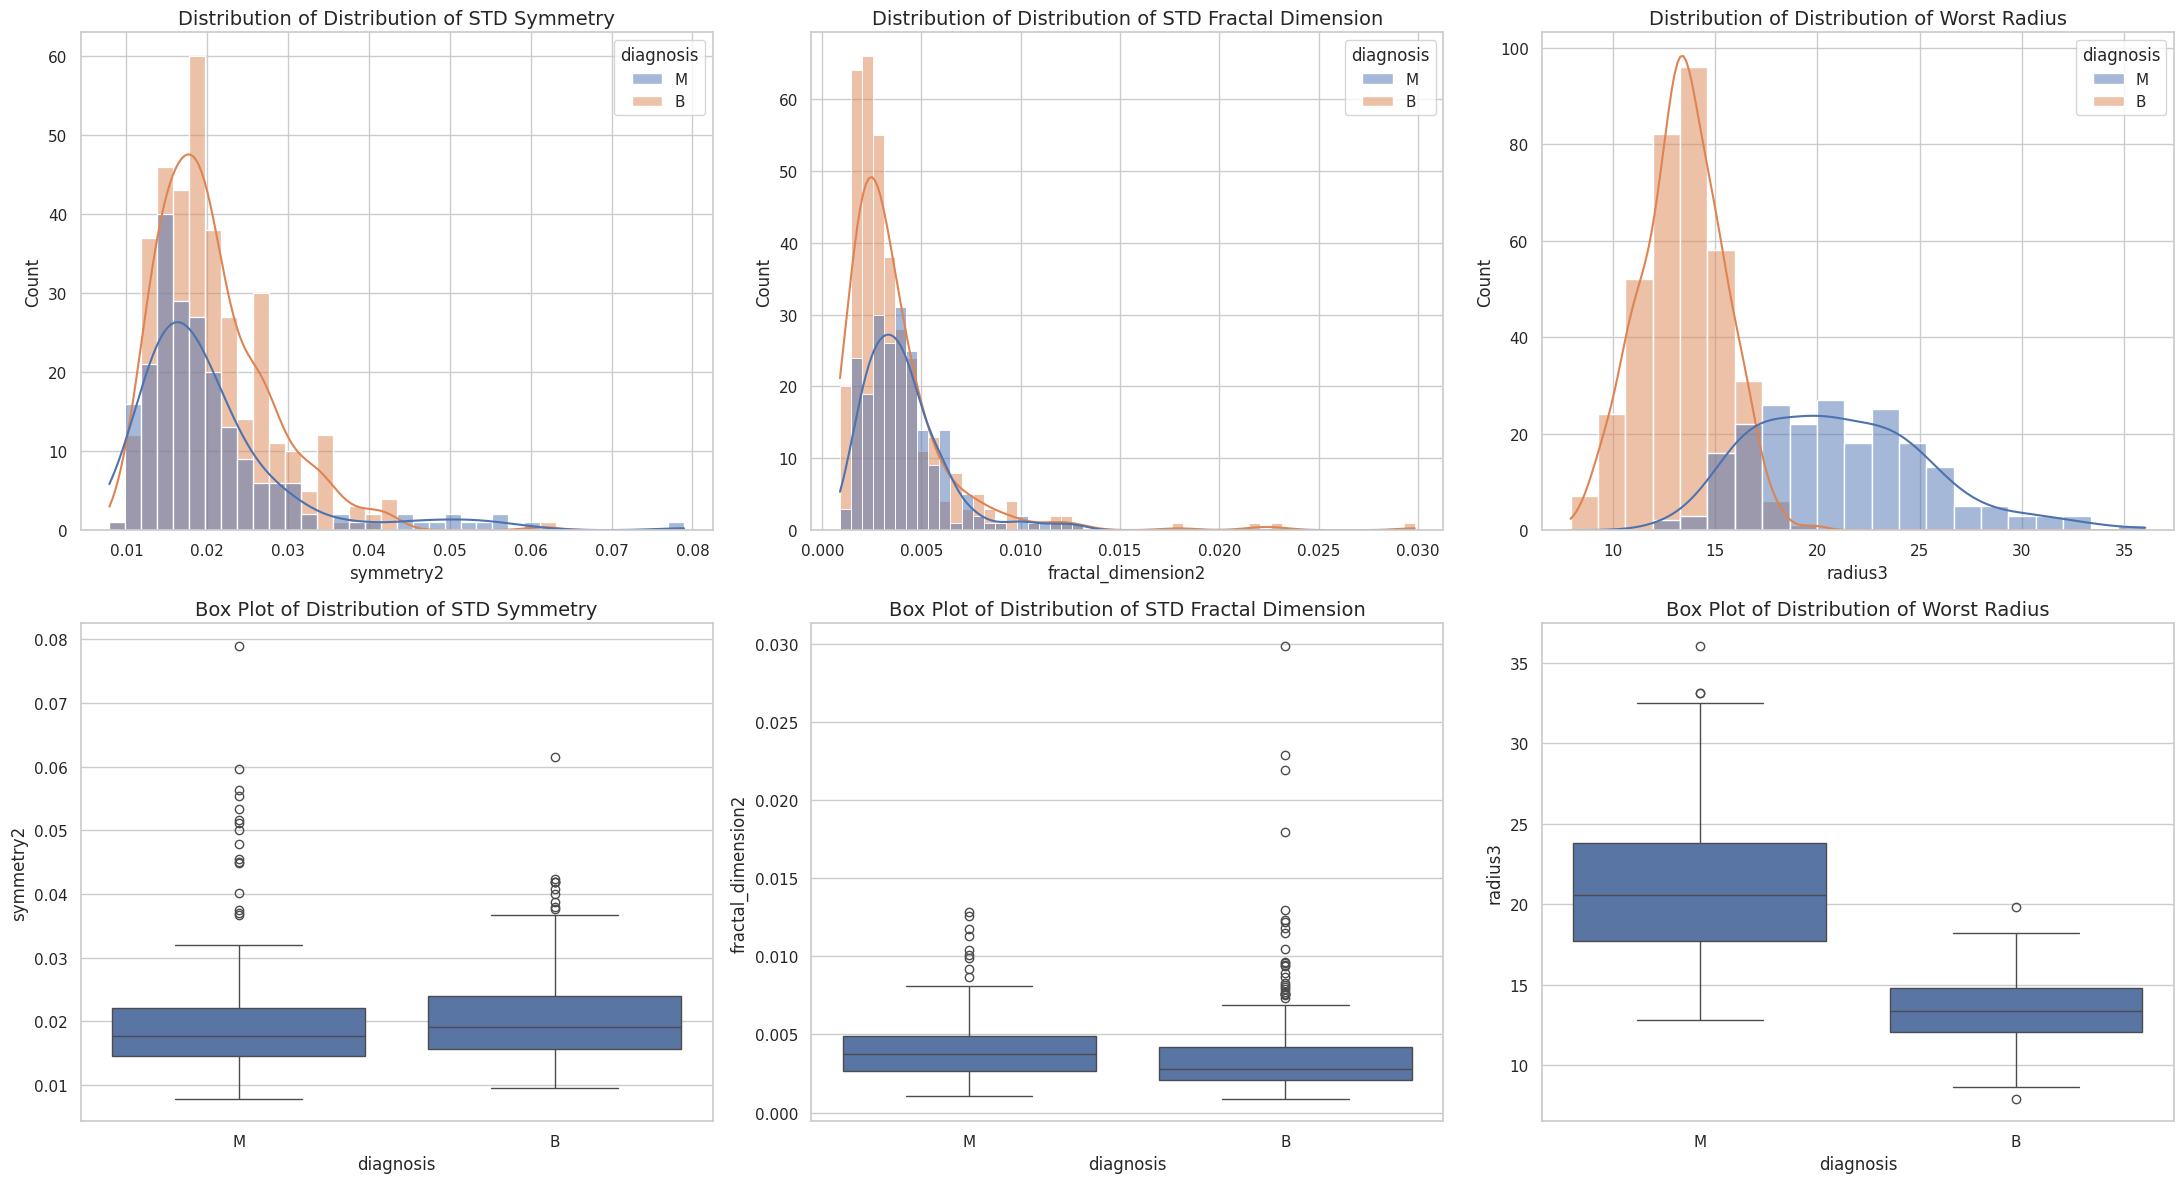

In [15]:
batch_7_features = feature_cols[18:21]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_7_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

With these three features we can clearly see that while the distribution of std symmetry and std fractal dimension is almost the same in the two classes, distribution of the worst radius is quite different and malignant tumors tend to have a higher worst (largest) radius

From the box plot we see that there are quite a few outliers for the std fractal dimension feature (especially for the benign class) while the worst radius doesn't have many outliers. This can also be seen in the histograms. 

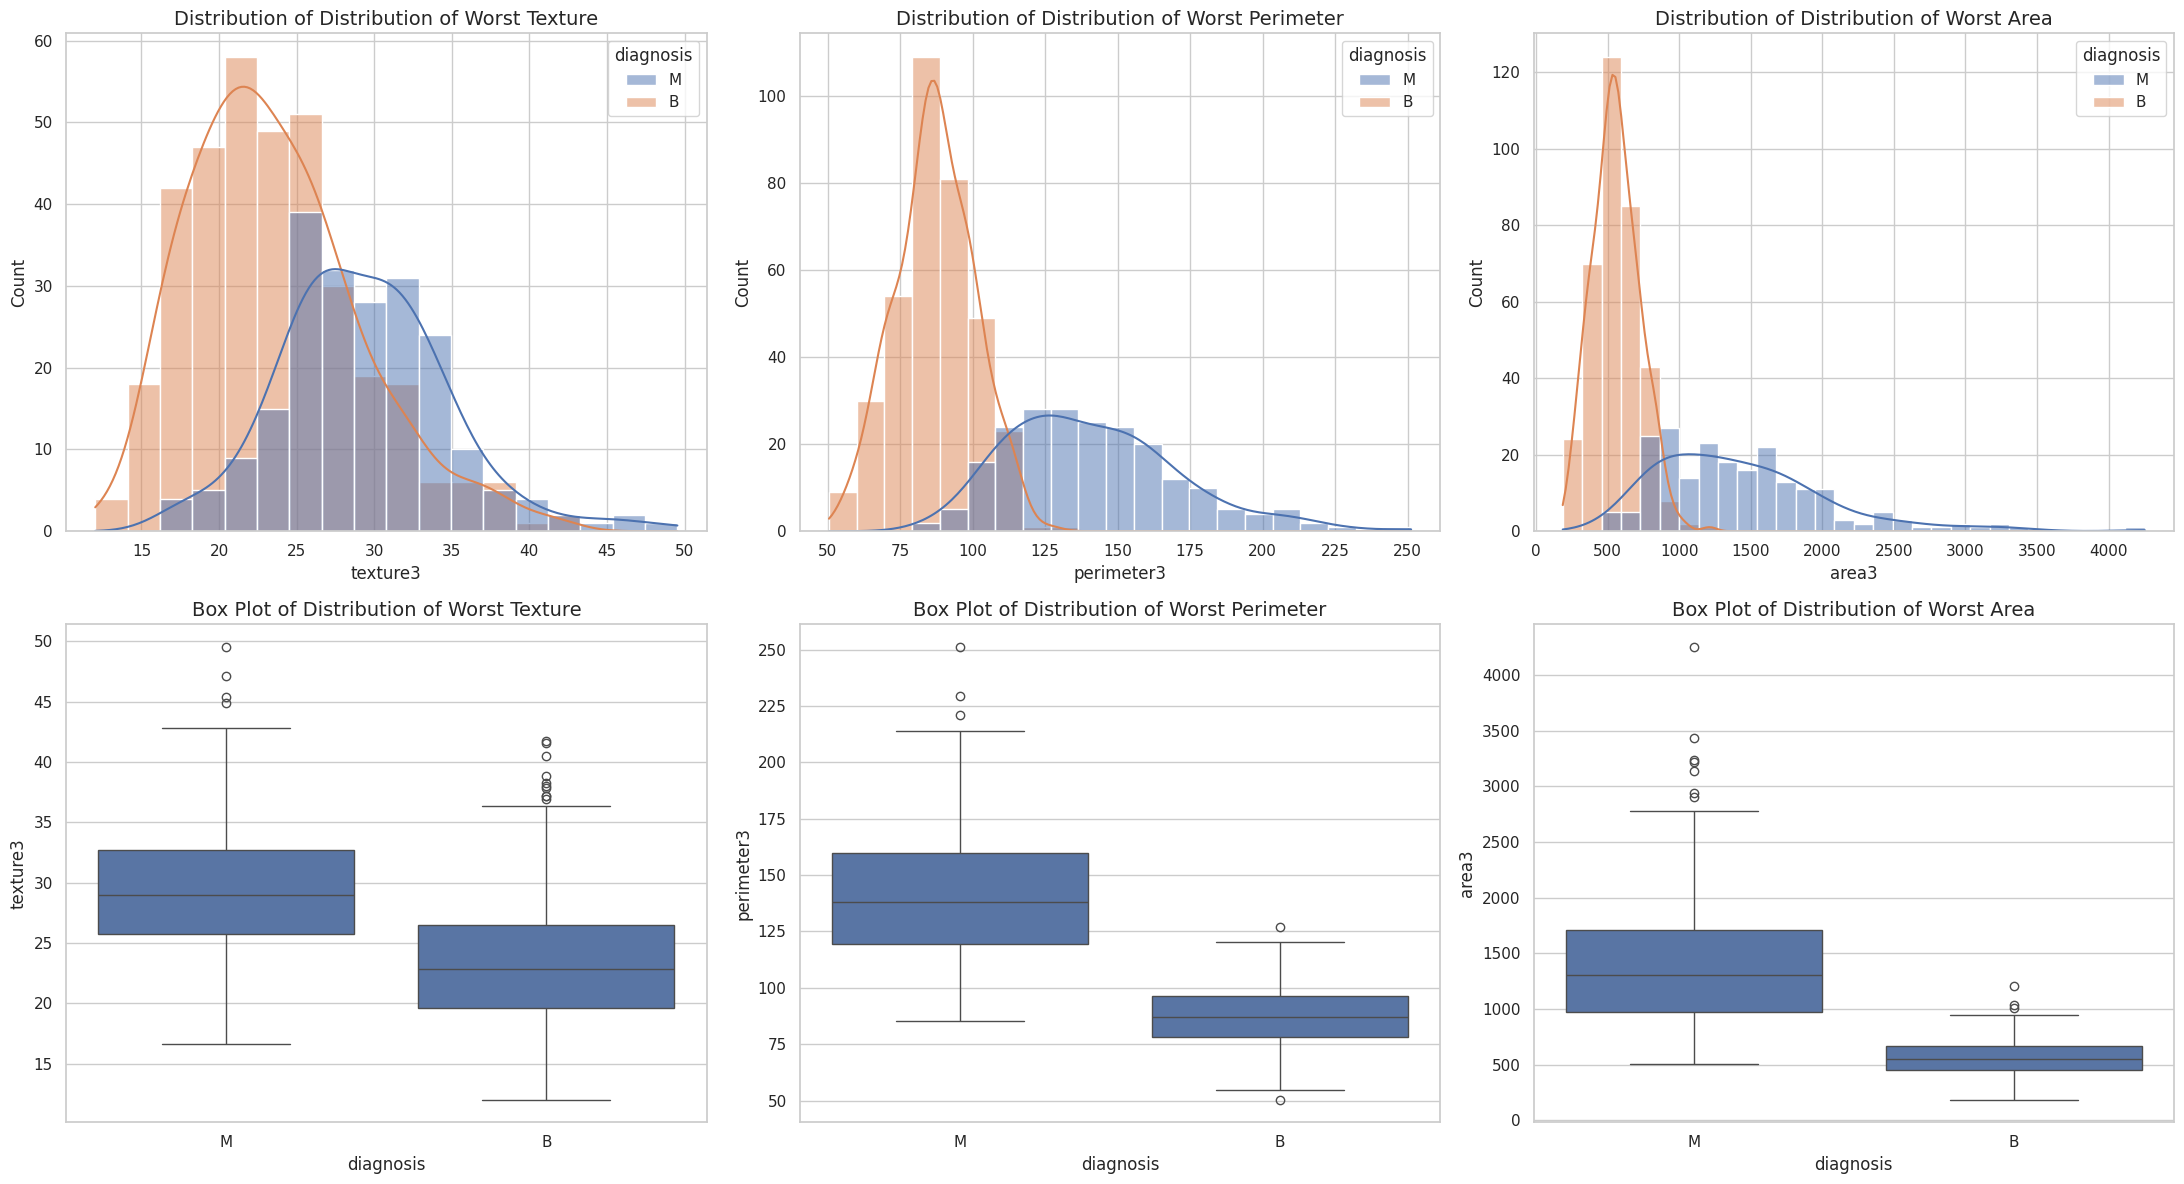

In [16]:
batch_8_features = feature_cols[21:24]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_8_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

We can see while there is a noticeable difference between the two classes in worst perimeter and worst area, the worst texture feature has a rather similar distribution in two classes which makes it less than ideal for our classifier.

From the box plots we can see that there aren't many outlier in the worst area and perimeter while the worst texture has quite a few outliers, especially in the benign class.

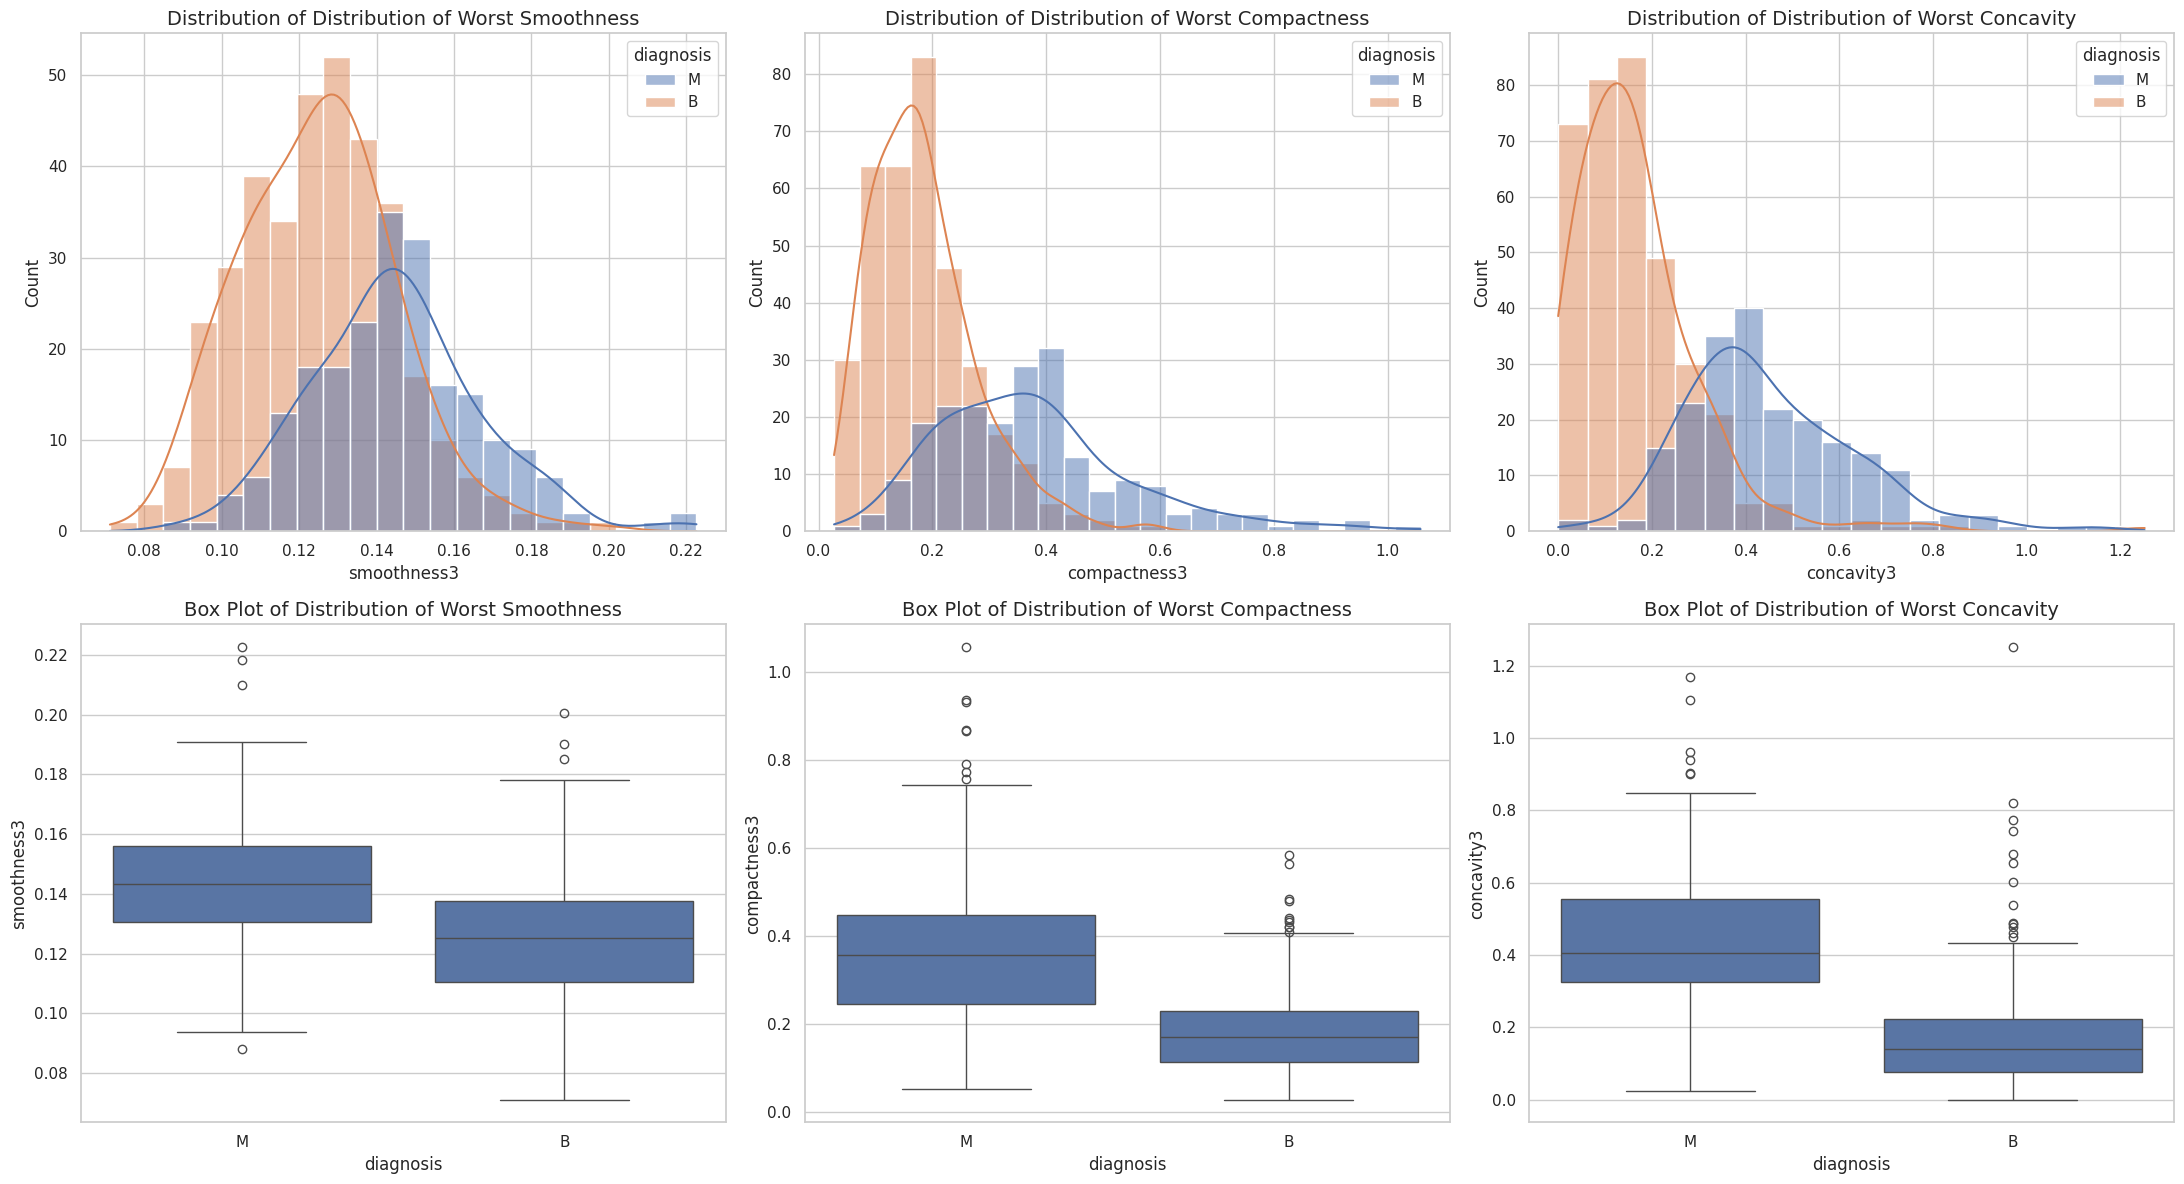

In [17]:
batch_9_features = feature_cols[24:27]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_9_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

This batch is similar to the last in that two of the features show a noticeably different distribution (worst compactness and concavity) while in the other one the distribution of the two classes are quite similar.

However from the box plots we can see that unlike the last batch, the feature of this batch (especially the two that had distinct histograms) have quite a few outliers!

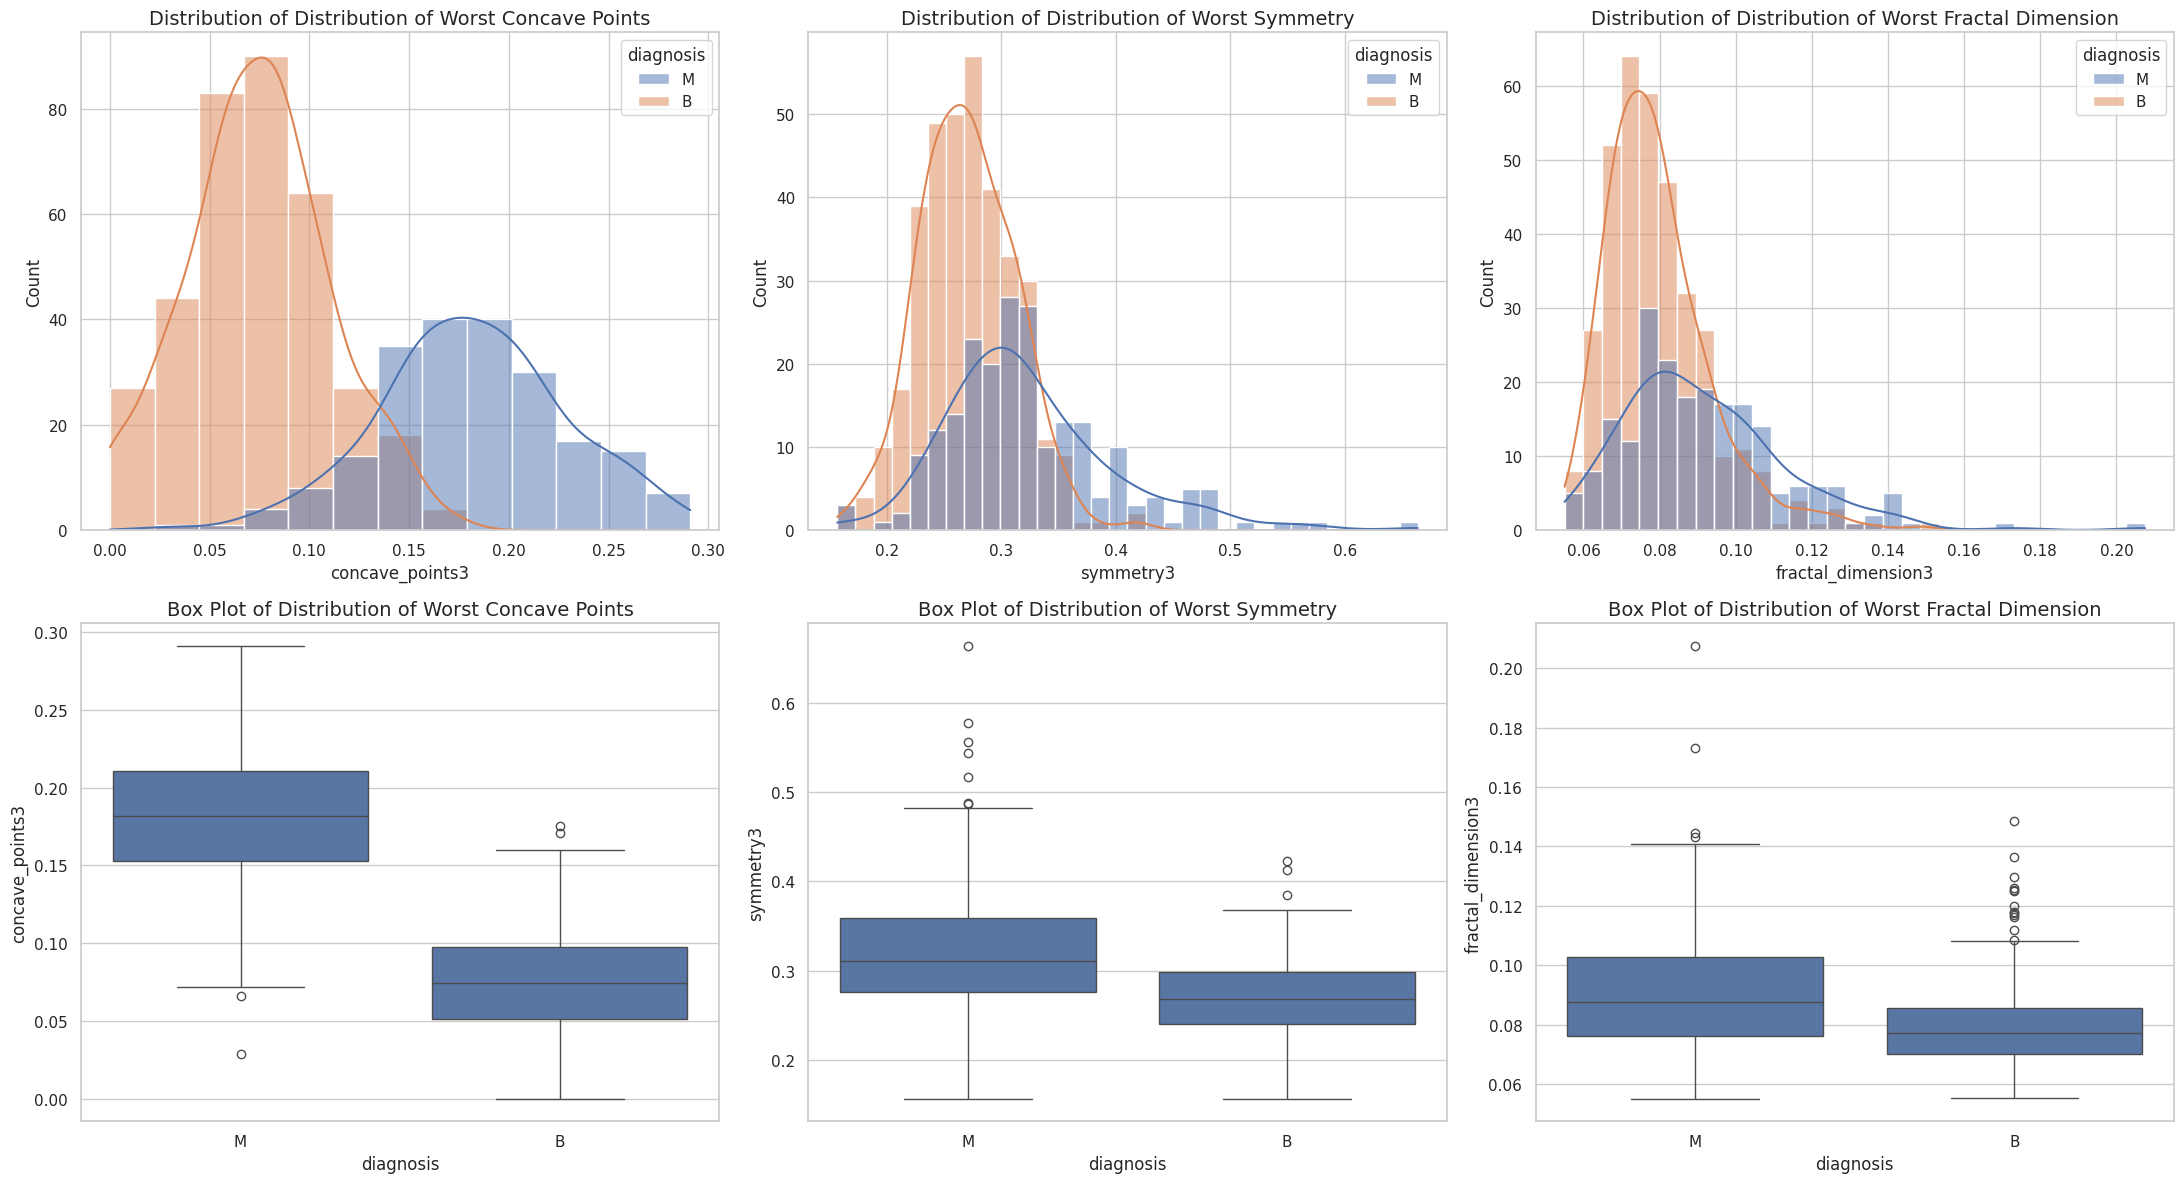

In [18]:
batch_10_features = feature_cols[27:30]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for i, feature in enumerate(batch_10_features):
    sns.histplot(data=cancer_dataset, x=feature, hue='diagnosis', kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution of {get_clean_title(feature)}', fontsize=14)
    
    sns.boxplot(data=cancer_dataset, x='diagnosis', y=feature, ax=axes[1, i])
    axes[1, i].set_title(f'Box Plot of {get_clean_title(feature)}', fontsize=14)

plt.tight_layout()
plt.show()

In this final batch we can see while the distribution of the two classes on the worst concave points is quite distinct and they don't have many outliers, the same can't be said about the other two feature as they both have many outliers and a very similar distribution!

#### 1.5.2. Correlation

Given the nature of the features of the dataset, we expect to see some highly correlated features (for example area and perimeter would probably be highly correlated).

To check this we calculate and draw a correlation heatmap.

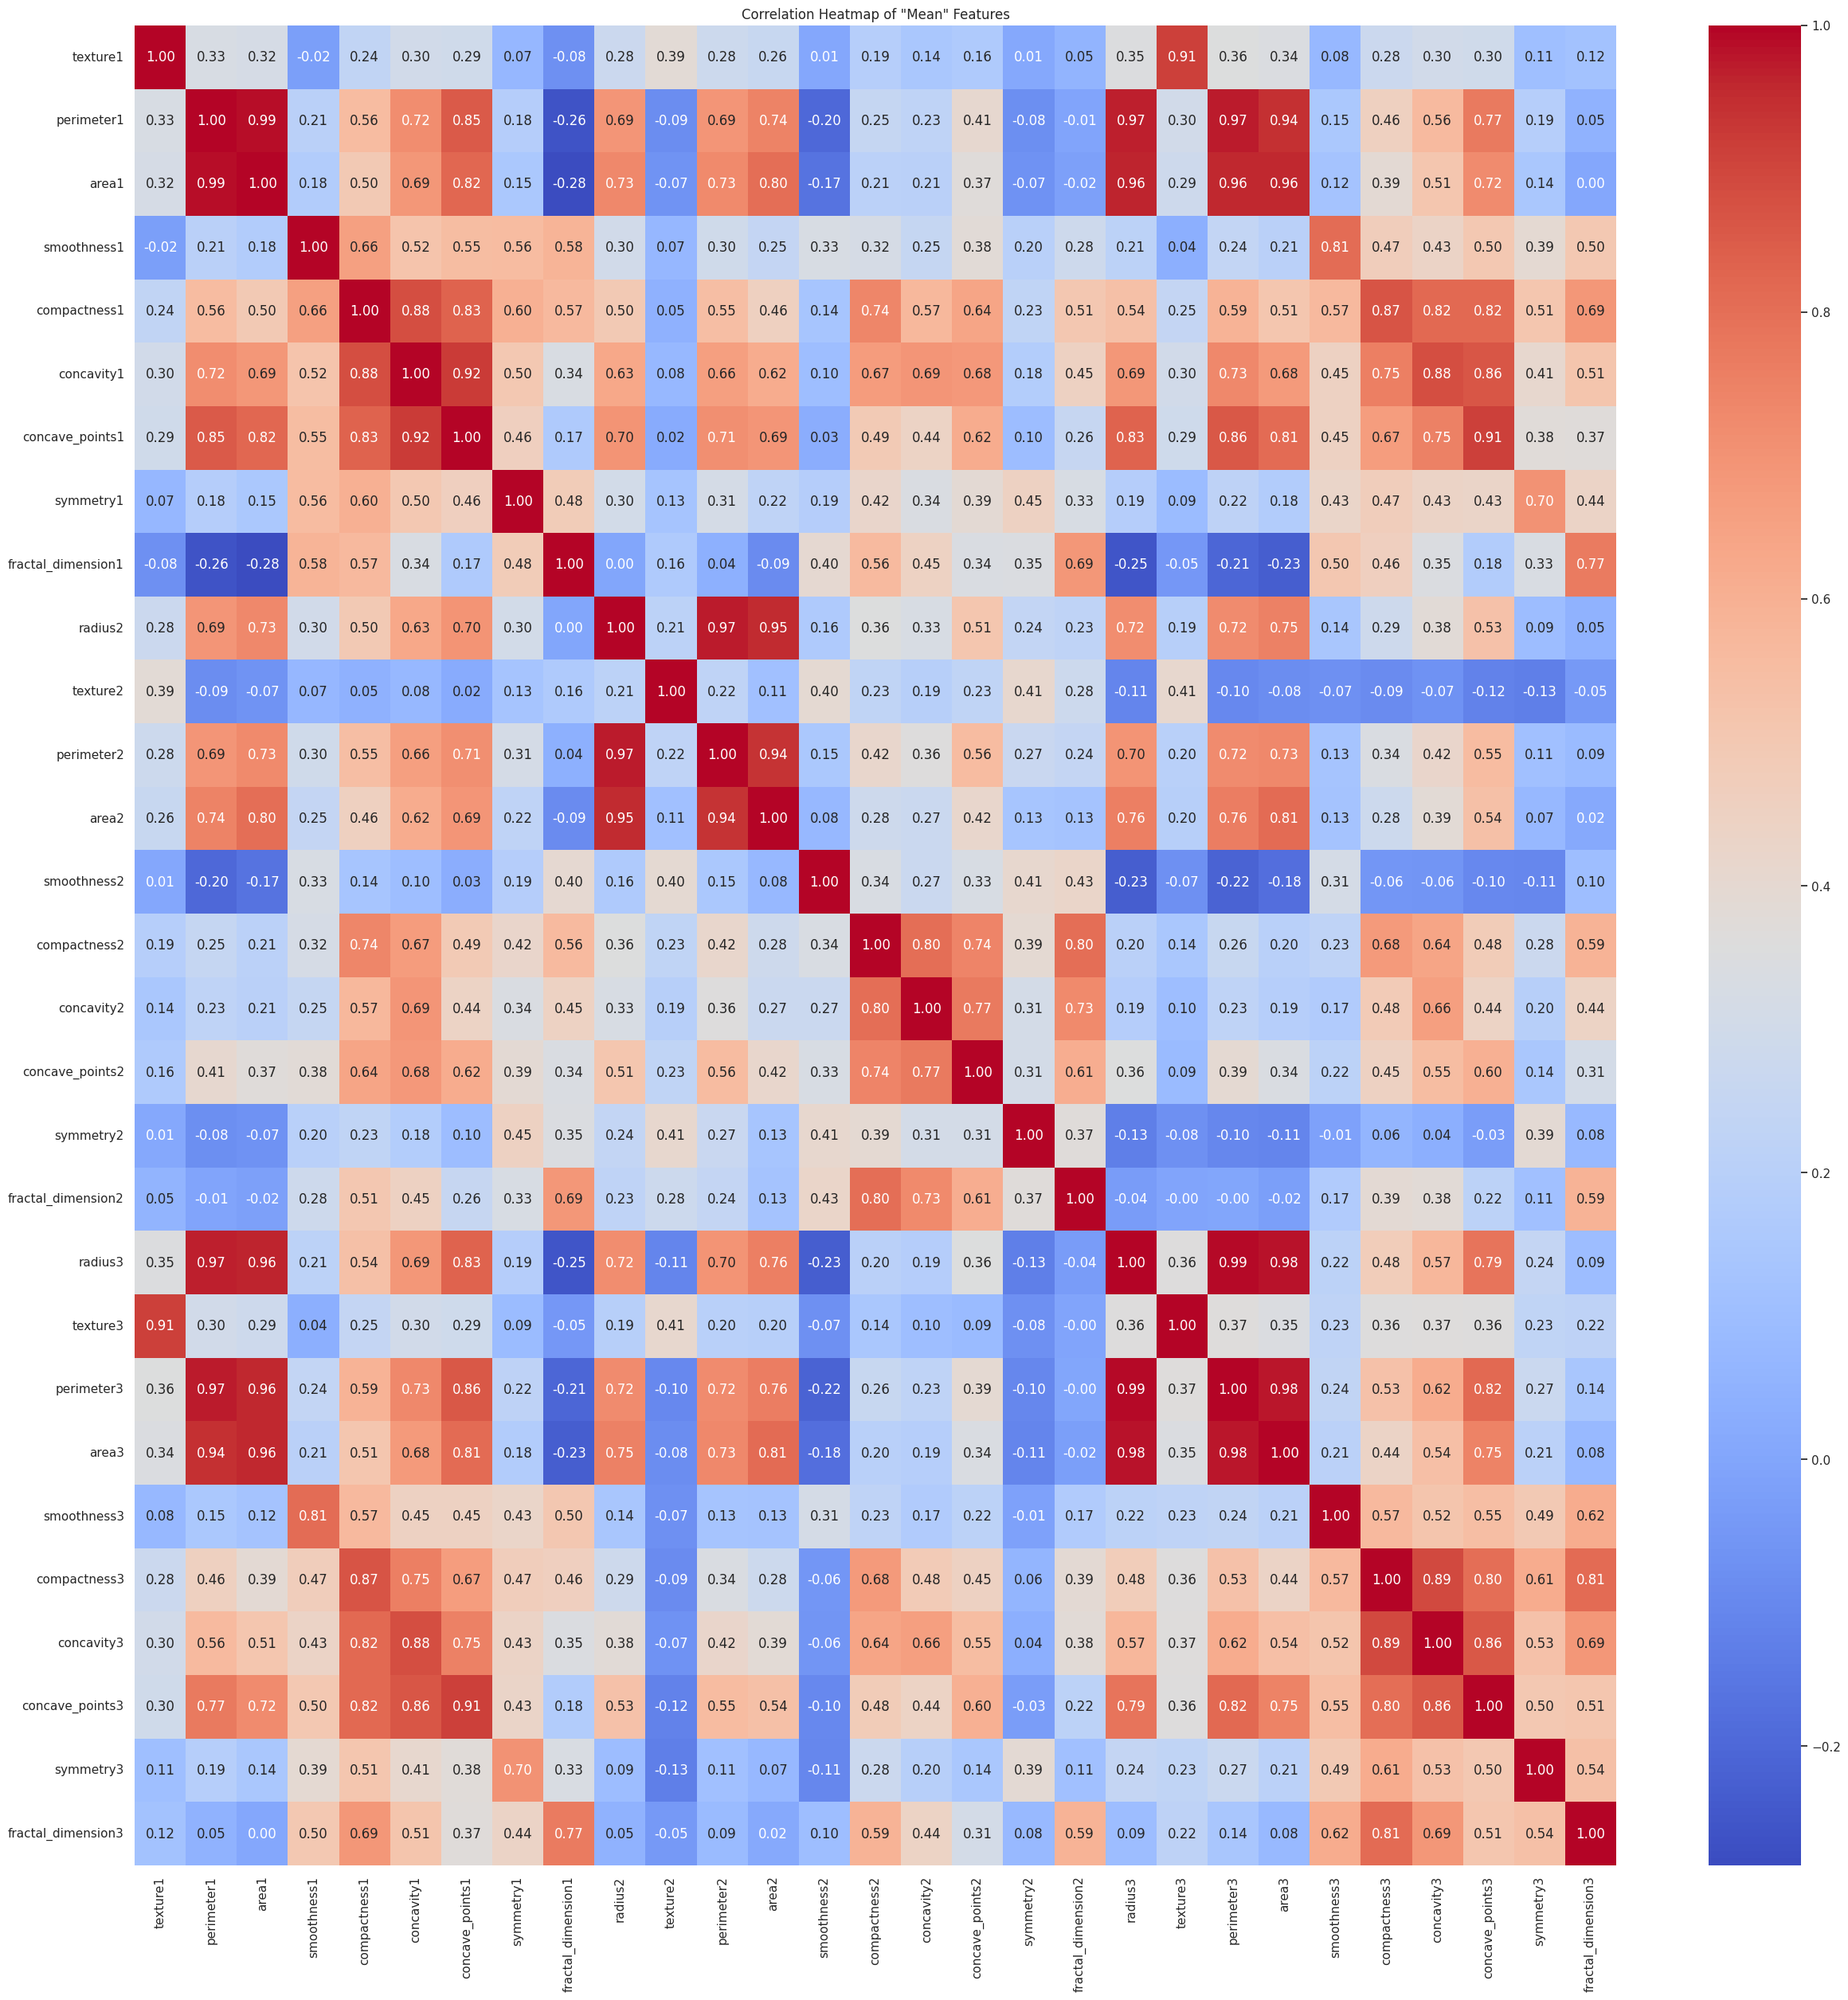

In [19]:
corr_matrix = cancer_dataset.iloc[:, 1:30].corr()

plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of "Mean" Features')
plt.show()

As expected, we can see that the perimeter, area and radius (both the mean, std and max) are highly correlated with each other. Furthermore we can see another correlation group: compactness, concavity and concave points which all related to the same overall concept.

There are also some other highly correlated feature (with a correlation of round 0.8) like concavity with fractal dimension and concave points with area and perimeter. 

Another expected correlation is between the three instances (mean, std and max) of the same features!

Multicollinearity can be problematic for us in the future as we would have to complicate our models by using multiple features that don't add any information. It can also reduce the the performance of some models. So we will be adding PCA to our pipeline to avoid all these issues and significantly reduce the size of our dataset (and the dimensions of the models) because almost 2/3 of the features are redundant!

## 2. Data Preprocessing

In this section we are going to handel missing values and split the dataset. We are not going to normalise the data here as we will be having a normalization step in the model training pipeline (just like the book!)

### 2.1. Missing values

Now let's take a look at the dataset and see how many missing values it has:

In [20]:
cancer_dataset.isnull().sum()

radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
diagnosis             0
dtype: int64

Fortunately the dataset doesn't have any missing values so we can proceed to the next step.

### 2.2. Normalization

As explained earlier, we will be including a normalization step in our pipeline so we will skip this step for now.

### 2.3. Splitting the dataset

In this section we will be splitting the dataset into 15% test (which will only be used at the very end for a final evaluation on the models) and 85% train. The reason we don't split the 15% validation set here is that we plan to use cross validation and grid/random-search for finding the best model and in the cross-validation, the data will automatically get splitted into train and validation while searching for the best model!

In [21]:
from sklearn.model_selection import train_test_split

random_state = 24

X = cancer_dataset.drop('diagnosis', axis=1)
y = cancer_dataset['diagnosis'].map({'M': 0, 'B': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=random_state, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test:  {X_test.shape}")

Shape of X_train: (483, 30)
Shape of X_test:  (86, 30)


## 3. Generating Features using Boosted Trees

In this section we are going to train a gradient boosting classifier, extract its leaf indices and convert them to numerical features and creating a new feature set to improve the SVM and LDA models we are going to train in the next section. But first let's explain what we are going to do and why it helps us in more detail:

### 3.1. Why generate features using trees?

Decision trees use a set of rules that helps them classify items, thus each leaf in a decision tree can be considered as a single rule. Here instead of using the final prediction of the tree we are going to use the id of the leaf each sample falls into (for example sample x may fall into leaf number 7) as a new feature. Since we are going to train 100 trees (using GradientBoostingClassifier) we will effectively create 100 new features for each sample (the id of the leaf in each tree that the specific sample falls into).

The main advantage of this approach is to boost models like SVM and LDA that are either linear or have a limited form of nonlinearity. The new features we have created are valuable for these models as they each represent a complex, nonlinear interaction of the original features (a rule) and they have been extracted using a powerful method such as gradient boosting.

### 3.2. Generating the new features

Here we will define a pipeline to train the gradient boosting classifier (forest). While trees don't necessarily need normalized features, since according to the book it's good practice to always include scalers we have included it here. A PCA step has also been added to handel the high correlation in the features.

The pipeline is then passed to a grid search to fine tune the parameters of the model (such as the number of components in PCA, number of estimators for the tree and the learning rate) to get the best model.

We will then use the leaves of this model to create the new feature set.

Let's begin by training the model:

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

feature_generator_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('gbc', GradientBoostingClassifier(random_state=42))
])

param_grid_generator = {
    'pca__n_components': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30],
    'gbc__n_estimators': [50, 100, 150, 200, 250],
    'gbc__learning_rate': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 1.5] 
}

print("Starting GridSearchCV")
grid_search_generator = GridSearchCV(
    feature_generator_pipeline, 
    param_grid=param_grid_generator,
    cv=5, 
    n_jobs=-1
)
grid_search_generator.fit(X_train, y_train)

print(f"Best parameters for the generator: {grid_search_generator.best_params_}")

Starting GridSearchCV
Best parameters for the generator: {'gbc__learning_rate': 0.5, 'gbc__n_estimators': 200, 'pca__n_components': 7}


Now we will use this generator to create the new feature set!

In [23]:
best_generator = grid_search_generator.best_estimator_

X_train_transformed = best_generator.named_steps['scaler'].transform(X_train)
X_train_transformed = best_generator.named_steps['pca'].transform(X_train_transformed)

X_test_transformed = best_generator.named_steps['scaler'].transform(X_test)
X_test_transformed = best_generator.named_steps['pca'].transform(X_test_transformed)

X_train_new_features = best_generator.named_steps['gbc'].apply(X_train_transformed).squeeze()
X_test_new_features = best_generator.named_steps['gbc'].apply(X_test_transformed).squeeze()

print(f"Shape of new features for X_train: {X_train_new_features.shape}")
print(f"Shape of new features for X_test:  {X_test_new_features.shape}")

Shape of new features for X_train: (483, 200)
Shape of new features for X_test:  (86, 200)


## 4 & 5. Training and tuning SVM & LDA

We are combining the steps 4 and 5 together as it makes more sense to train and fine tune the model at the same time, so in this section we will first train a SVM model and in our pipeline for model training we will first scale the features then perform feature selection  (using SelectKBest) and then train the model. The hyper parameters of the model and the number of selected features will be chosen using randomized search. 

After the model is trained we will use the learning curves to diagnose any potential issues and if the model is not working properly, for example if the scores on training and validation (cross validation) are too far apart, we can understand that the model has overfitted and need to change the parameter os the random search. Or if they both are well below a good threshold (like 90%) we can assume that the model didn't have enough complexity. We will repeat the process until we arrive at an acceptable model (the code below would only have the final version!)

We will then repeat a similar process for the LDA and at the end we will evaluate both models on the test data (we can only use the test data once since it shouldn't impact our model selection and tuning in any way!) and compare their performances!

### (4 & 5).1 SVM

Let's begin by training the SVM model

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
# The corrected import line is here
from scipy.stats import randint, loguniform, uniform

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('classifier', SVC(probability=True, random_state=42)) 
])

param_dist_svm_expanded = {
    'selector__k': randint(5, 201),
    
    'classifier__kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    
    'classifier__C': loguniform(1e-3, 1e2),
    
    'classifier__gamma': loguniform(1e-4, 1e-1),
    
    'classifier__degree': randint(1, 7),
    
    'classifier__coef0': uniform(0, 1)
}

print("Starting RandomizedSearchCV")
random_search_svm = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=param_dist_svm_expanded,
    n_iter=700,
    cv=5,
    n_jobs=-1,
    random_state=random_state,
    verbose=1
)

random_search_svm.fit(X_train_new_features, y_train)

best_svm_model = random_search_svm.best_estimator_

print("--- Search Complete ---")
print(f"Best parameters found for SVM: {random_search_svm.best_params_}")
print(f"Best cross-validation score (accuracy) for SVM: {random_search_svm.best_score_:.4f}")

Starting RandomizedSearchCV
Fitting 5 folds for each of 700 candidates, totalling 3500 fits


/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/p

--- Search Complete ---
Best parameters found for SVM: {'classifier__C': np.float64(0.03306554930459541), 'classifier__coef0': np.float64(0.9381421840234249), 'classifier__degree': 3, 'classifier__gamma': np.float64(0.03154289233630688), 'classifier__kernel': 'linear', 'selector__k': 130}
Best cross-validation score (accuracy) for SVM: 0.9835


/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/p

Here are the results of the training (it was hard to read amongst all the other messages so I copied it here, if the code is ran again the results might be slightly different):

--- Search Complete ---

Best parameters found for SVM: {
    'classifier__C': np.float64(0.04978033232181104),
     
    'classifier__coef0': np.float64(0.8058874128872235),
     
    'classifier__degree': 3,
     
    'classifier__gamma': np.float64(0.0017017271778523289),
     
    'classifier__kernel': 'linear',
     
    'selector__k': 100
}

Best cross-validation score (accuracy) for SVM: 0.9835

Now let's draw the learning curve to identify any potential issues

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve_with_ci(estimator, title, X, y, cv=5):
    """
    Generates a plot of the learning curve with confidence intervals.
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.grid(True)
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.show()

/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/p

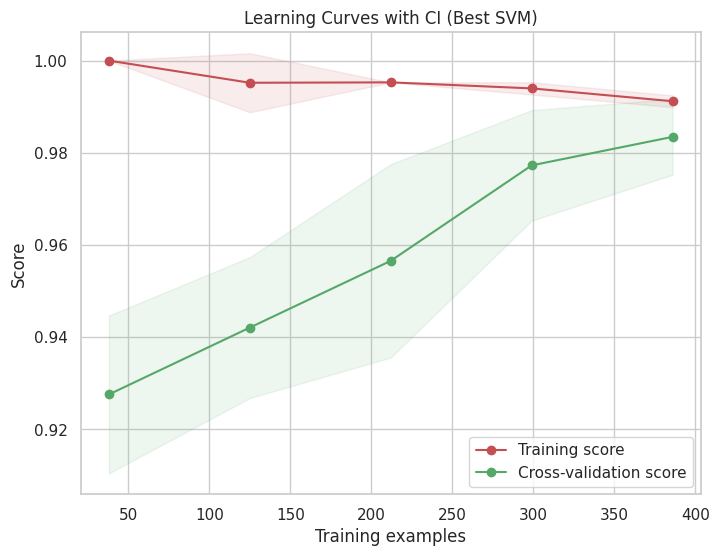

In [26]:
plot_learning_curve_with_ci(
    best_svm_model, 
    "Learning Curves with CI (Best SVM)", 
    X_train_new_features, 
    y_train, 
    cv=5
)

After doing the process of training the model and drawing the plot, then changing the range of parameters several times, we arrive at this plot. At first glance, it might seem like the model hasn't been trained properly (there is a gap between train and validation score). However, it should be noted that the whole range of the graph is 8%, so any visual difference is highly exaggerated

### (4 & 5).1 LDA

Now let's repeat a similar process with the LDA classifier

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

lda_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('classifier', LinearDiscriminantAnalysis())
])

param_dist_lda = [
    { 
        'selector__k': randint(5, 201),
        'classifier__solver': ['svd']
    },
    {
        'selector__k': randint(5, 201),
        'classifier__solver': ['lsqr', 'eigen'],
        'classifier__shrinkage': uniform(0, 1)
    }
]

print("Starting RandomizedSearchCV for LDA.")
random_search_lda = RandomizedSearchCV(
    lda_pipeline,
    param_distributions=param_dist_lda,
    n_iter=300,
    cv=5,
    n_jobs=-1,
    random_state=random_state,
    verbose=1
)

random_search_lda.fit(X_train_new_features, y_train)

best_lda_model = random_search_lda.best_estimator_

print("--- Search Complete ---")
print(f"Best parameters found for LDA: {random_search_lda.best_params_}")
print(f"Best cross-validation score (accuracy) for LDA: {random_search_lda.best_score_:.4f}")

Starting RandomizedSearchCV for LDA.
Fitting 5 folds for each of 300 candidates, totalling 1500 fits


/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/p

--- Search Complete ---
Best parameters found for LDA: {'classifier__shrinkage': np.float64(0.010994743642253946), 'classifier__solver': 'eigen', 'selector__k': 132}
Best cross-validation score (accuracy) for LDA: 0.9731


The final results and parameters were:

--- Search Complete ---
Best parameters found for LDA: {
    'classifier__shrinkage': np.float64(0.005184862773986776),
    
    'classifier__solver': 'eigen',
    
    'selector__k': 177
    
}

Best cross-validation score (accuracy) for LDA: 0.9752

Now let's draw the learning curve.

/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/p

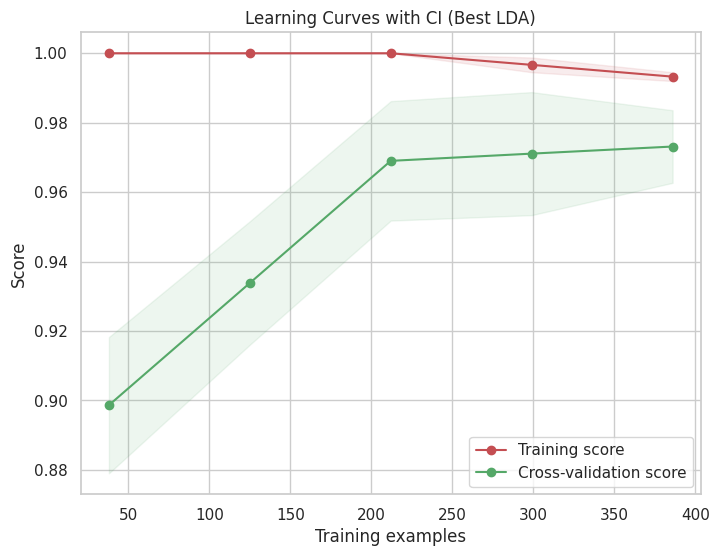

In [31]:
plot_learning_curve_with_ci(
    best_lda_model, 
    "Learning Curves with CI (Best LDA)", 
    X_train_new_features, 
    y_train, 
    cv=5
)

After some iterations, we arrive at this plot. Similar to the SVM graph its large visual difference can be misleading. While it's not as good as the SVM plot (and there is a 2% difference between test and validation accuracy) it still shows the model was trained properly and achieved an acceptable score.

### (4 & 5).3. Model Comparison

Now as the final step, we will use metrics such as precision, recall, accuracy and f1-score to compare the model's performance on the test data. We will also calculate the confusion matrix and draw the ROC plot.

Let's begin by calculating the numerical metrics:

In [32]:
import pandas as pd
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_svm = best_svm_model.predict(X_test_new_features)
y_prob_svm = best_svm_model.predict_proba(X_test_new_features)[:, 1]

# LDA Predictions
y_pred_lda = best_lda_model.predict(X_test_new_features)
y_prob_lda = best_lda_model.predict_proba(X_test_new_features)[:, 1]

print("--- SVM Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=['Malignant', 'Benign']))

print("--- LDA Classification Report ---")
print(classification_report(y_test, y_pred_lda, target_names=['Malignant', 'Benign']))

metrics = {
    'Accuracy': [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_lda)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_svm), roc_auc_score(y_test, y_prob_lda)],
    'Precision (M)': [precision_score(y_test, y_pred_svm, pos_label=0), precision_score(y_test, y_pred_lda, pos_label=0)],
    'Recall (M)': [recall_score(y_test, y_pred_svm, pos_label=0), recall_score(y_test, y_pred_lda, pos_label=0)],
    'F1-Score (M)': [f1_score(y_test, y_pred_svm, pos_label=0), f1_score(y_test, y_pred_lda, pos_label=0)]
}
metrics_df = pd.DataFrame(metrics, index=['SVM', 'LDA'])
print("--- Side-by-Side Comparison (Malignant Class is 0) ---")
print(metrics_df)

--- SVM Classification Report ---
              precision    recall  f1-score   support

   Malignant       1.00      0.94      0.97        32
      Benign       0.96      1.00      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.97        86
weighted avg       0.98      0.98      0.98        86

--- LDA Classification Report ---
              precision    recall  f1-score   support

   Malignant       0.97      0.94      0.95        32
      Benign       0.96      0.98      0.97        54

    accuracy                           0.97        86
   macro avg       0.97      0.96      0.96        86
weighted avg       0.97      0.97      0.96        86

--- Side-by-Side Comparison (Malignant Class is 0) ---
     Accuracy   ROC-AUC  Precision (M)  Recall (M)  F1-Score (M)
SVM  0.976744  0.984954       1.000000      0.9375      0.967742
LDA  0.965116  0.979167       0.967742      0.9375      0.952381


As we can see, both models had quite a good generalization on the unseen test data. The SVM was slightly higher in all the metrics with a 97.67% accuracy and a perfect precision score. However, LDA still performed quite well too, with a 96.51% accuracy and being behind SVM by only a couple of percent in other categories.

Now let's move onto the confusion matrix.

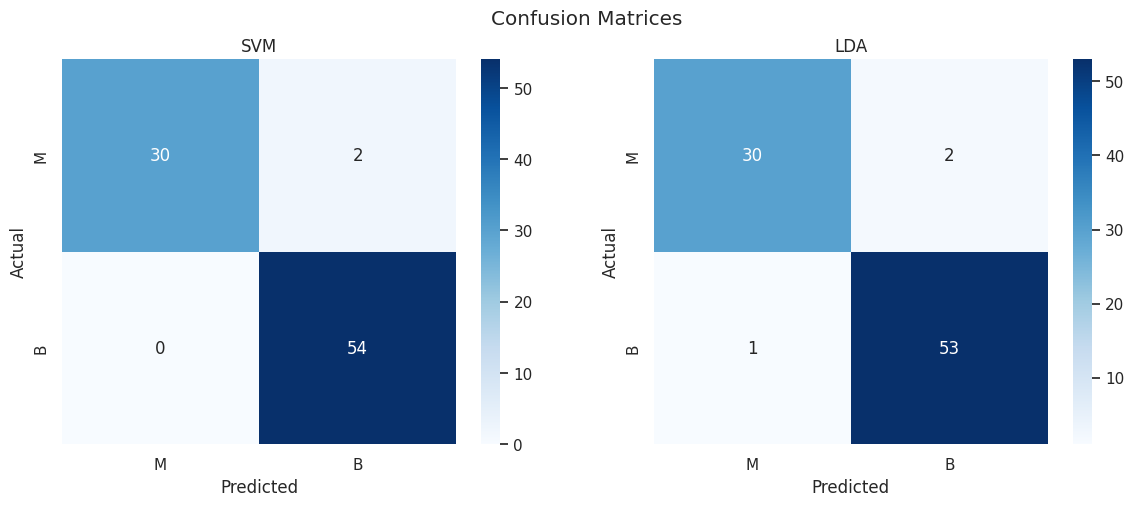

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices')

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['M', 'B'], yticklabels=['M', 'B'])
axes[0].set_title('SVM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lda = confusion_matrix(y_test, y_pred_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=['M', 'B'], yticklabels=['M', 'B'])
axes[1].set_title('LDA')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.show()

From the confusion matrix, we can see that both models almost classified everything perfectly. The SVM only had two false positives, while the LDA had two false positives and a false negative.

For the last plot we are going to draw the ROC curve and calculate the AUC score.

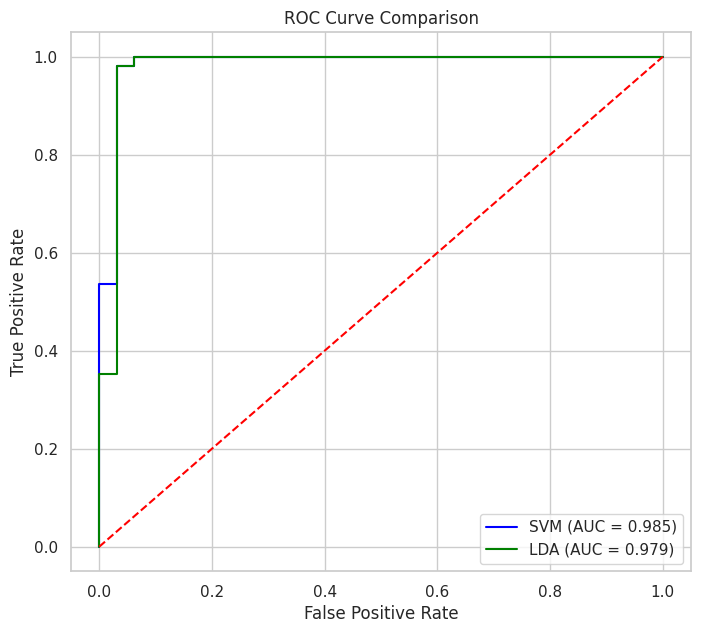

In [34]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_lda)

plt.figure(figsize=(8, 7))
plt.plot(fpr_svm, tpr_svm, color='blue', label=f'SVM (AUC = {metrics_df.loc["SVM", "ROC-AUC"]:.3f})')
plt.plot(fpr_lda, tpr_lda, color='green', label=f'LDA (AUC = {metrics_df.loc["LDA", "ROC-AUC"]:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

Again, both models did an exceptional job. The SVM model had a slightly higher AUC score (0.985), while LDA got a respectable 0.979.